<center>

# ***Trabajo Práctico Nro 1 - Continual Learning***

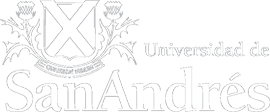

### **Asignatura:** Visión Artificial Avanzada (I309)

### **Alumnos:** Mateo Giacometti y Tiziano Leví Martín Bernal

### **Profesores:** Gastón Castro, Agustín Roca y Francisco Gómez  

### **Fecha:** 30/04/2026

</center>

## **Imports**

In [1]:
from pathlib import Path
import math
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader

sys.path.append(str(Path.cwd() / "src"))

from tp1_cl import *
from tp1_cl.models import SupConLoss, SupConNetwork


cfg = load_config("configs/cifar10.yaml")
set_seed(int(cfg.training.seed))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ckpt_dir = ensure_checkpoint_dir(cfg.outputs.checkpoints)

def ckpt(name: str) -> Path:
    return ckpt_dir / name

Using device: cuda


## **Preparacion del dataset**

In [2]:
FORCE_RETRAIN = False

num_workers = int(cfg.training.num_workers) if torch.cuda.is_available() else min(4, int(cfg.training.num_workers))
dataloader_kwargs = {
    "num_workers": num_workers,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": num_workers > 0,
}

if num_workers > 0:
    dataloader_kwargs["prefetch_factor"] = int(cfg.training.dataloader.prefetch_factor)

transform_cfg = TransformConfig(
    mean=tuple(cfg.transforms.mean),
    std=tuple(cfg.transforms.std),
    crop_size=int(cfg.transforms.crop_size),
    crop_scale=tuple(cfg.transforms.crop_scale),
    hflip_prob=float(cfg.transforms.hflip_prob),
    color_jitter_values=tuple(cfg.transforms.color_jitter_values),
    color_jitter_prob=float(cfg.transforms.color_jitter_prob),
    grayscale_prob=float(cfg.transforms.grayscale_prob),
)
eval_transform, supcon_train_transform = build_transforms(transform_cfg)

task_cfg = TaskConfig(
    n_tasks=int(cfg.data.n_tasks),
    classes_per_task=int(cfg.data.classes_per_task),
    class_order=list(cfg.data.class_order),
    shuffle_class_order=False,
    seed=int(cfg.training.seed),
)
seq_builder = SeqCIFAR10Builder(root=cfg.data.root, config=task_cfg)

task_train_loaders, task_test_loaders = seq_builder.build_task_loaders(
    batch_size=int(cfg.training.batch_size),
    transform=eval_transform,
    train_shuffle=True,
    num_workers=num_workers,
    loader_kwargs=dataloader_kwargs,
)

In [3]:
print("Seq-CIFAR-10 split summary")
for row in seq_builder.summary_rows():
    print(
        f"Task {row['task_id']}: Classes = {row['class_names']} | Train Set = {row['n_train']} | Test Set = {row['n_test']}"
    )

replay_buffer = ReservoirReplayBuffer(capacity=int(cfg.data.buffer_size), seed=int(cfg.training.seed))
demo_images, demo_labels = next(iter(task_train_loaders[0]))
replay_buffer.add(demo_images, demo_labels)
sample_images, sample_labels = replay_buffer.sample(batch_size=16)
print(
    f"Replay buffer size = {len(replay_buffer)} / {int(cfg.data.buffer_size)} | Sample = {sample_images.shape}, Labels = {sample_labels.shape}"
)

Seq-CIFAR-10 split summary
Task 0: Classes = ['airplane', 'automobile'] | Train Set = 10000 | Test Set = 2000
Task 1: Classes = ['bird', 'cat'] | Train Set = 10000 | Test Set = 2000
Task 2: Classes = ['deer', 'dog'] | Train Set = 10000 | Test Set = 2000
Task 3: Classes = ['frog', 'horse'] | Train Set = 10000 | Test Set = 2000
Task 4: Classes = ['ship', 'truck'] | Train Set = 10000 | Test Set = 2000
Replay buffer size = 200 / 200 | Sample = torch.Size([16, 3, 32, 32]), Labels = torch.Size([16])


## Pre-entrenamiento SupCon

In [4]:
task0_classes = seq_builder.task_classes[0]
task0_class_names = [CIFAR10_CLASSES[c] for c in task0_classes]

task0_train_raw = seq_builder.get_task_dataset(task_id=0, train=True, transform=None)
task0_contrastive_ds = ContrastiveTaskDataset(
    task_dataset=task0_train_raw,
    two_crop_transform=TwoCropTransform(supcon_train_transform),
)
task0_contrastive_loader = DataLoader(
    task0_contrastive_ds,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    drop_last=True,
    **dataloader_kwargs,
)

task0_eval_loader = DataLoader(
    seq_builder.get_task_dataset(task_id=0, train=False, transform=eval_transform),
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

backbone, feat_dim = build_cifar_resnet(model_name="resnet18")
supcon_model = SupConNetwork(
    backbone=backbone,
    feat_dim=feat_dim,
    proj_dim=int(cfg.supcon.proj_dim),
).to(device)
supcon_criterion = SupConLoss(
    temperature=float(cfg.supcon.temperature),
    base_temperature=float(cfg.supcon.base_temperature),
)
supcon_optimizer = torch.optim.SGD(
    supcon_model.parameters(),
    lr=float(cfg.supcon.lr),
    momentum=float(cfg.supcon.momentum),
    weight_decay=float(cfg.supcon.weight_decay),
)

supcon_epochs = int(cfg.supcon.epochs)
warmup_epochs = int(cfg.supcon.warmup_epochs)

def supcon_lr_lambda(epoch: int) -> float:
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(max(1, warmup_epochs))
    if supcon_epochs == warmup_epochs:
        return 1.0
    progress = float(epoch - warmup_epochs) / float(supcon_epochs - warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

supcon_scheduler = torch.optim.lr_scheduler.LambdaLR(
    supcon_optimizer, lr_lambda=supcon_lr_lambda
)

snapshot_epochs = {max(1, supcon_epochs // 2): "mitad", supcon_epochs: "final"}
supcon_ckpt = ckpt("task0_supcon.pt")

if supcon_ckpt.exists():
    payload = load_checkpoint(supcon_ckpt, map_location=device)
    supcon_model.load_state_dict(payload["model"])
    supcon_losses = payload["losses"]
    embedding_snapshots = payload["snapshots"]
    print(f"Loaded checkpoint: {supcon_ckpt}")
else:
    supcon_losses, embedding_snapshots = train_supcon(
        model=supcon_model,
        train_loader=task0_contrastive_loader,
        eval_loader_for_snapshots=task0_eval_loader,
        criterion=supcon_criterion,
        optimizer=supcon_optimizer,
        device=device,
        epochs=supcon_epochs,
        snapshot_epochs=snapshot_epochs,
        scheduler=supcon_scheduler,
    )
    save_checkpoint(
        supcon_ckpt,
        {
            "model": supcon_model.state_dict(),
            "losses": supcon_losses,
            "snapshots": embedding_snapshots,
        },
    )
    print(f"Saved checkpoint: {supcon_ckpt}")

Loaded checkpoint: outputs/checkpoints/task0_supcon.pt


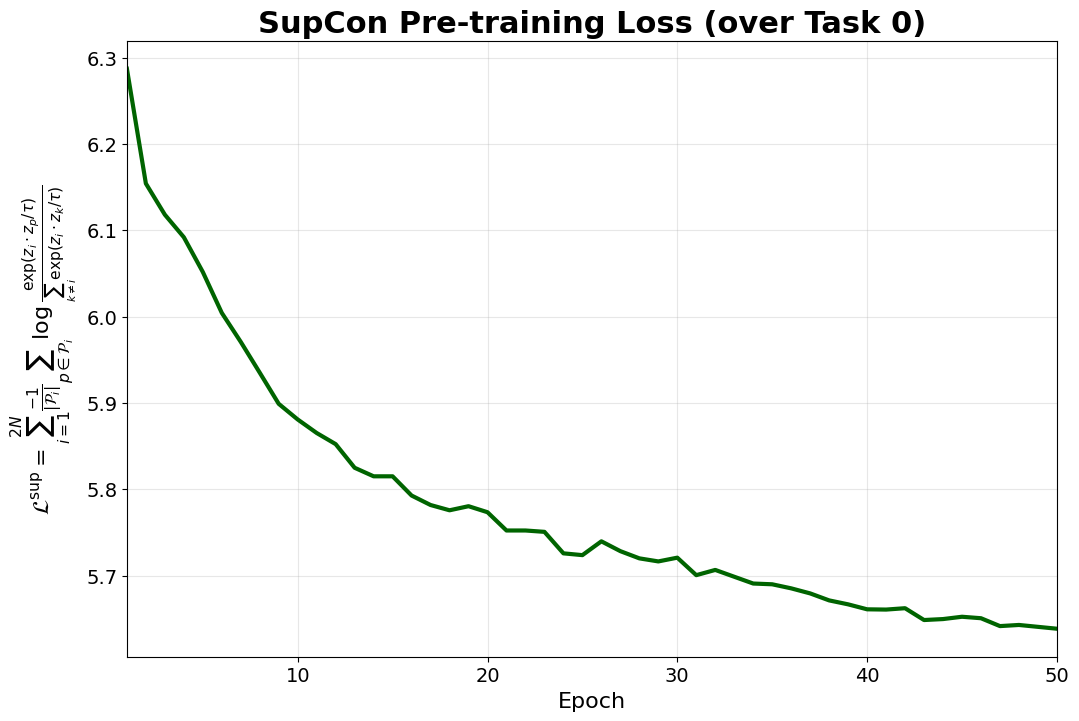

In [5]:
plot_supcon_loss(supcon_losses, save_path=Path(cfg.outputs.root) / "imgs" / "supcon_loss.png")

/home/tiziano/anaconda3/envs/vaa_tp1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tiziano/anaconda3/envs/vaa_tp1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tiziano/anaconda3/envs/vaa_tp1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


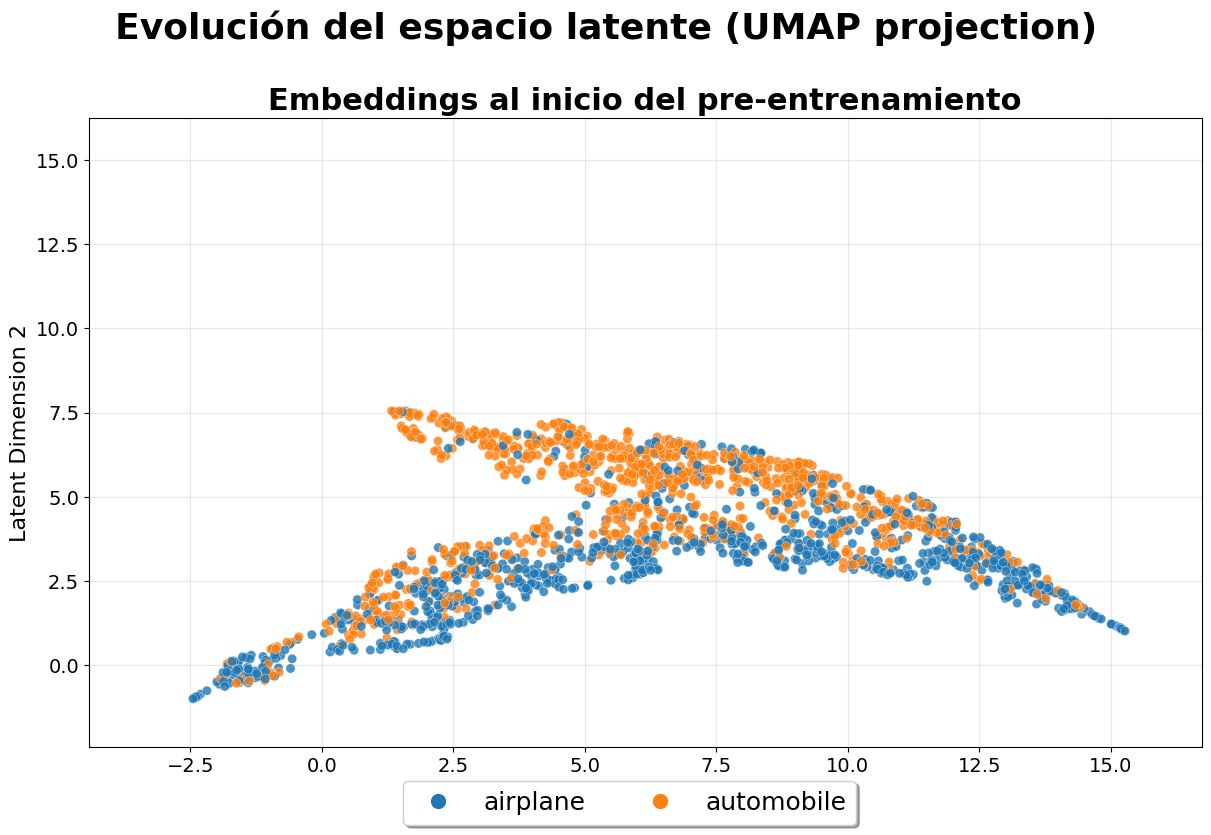

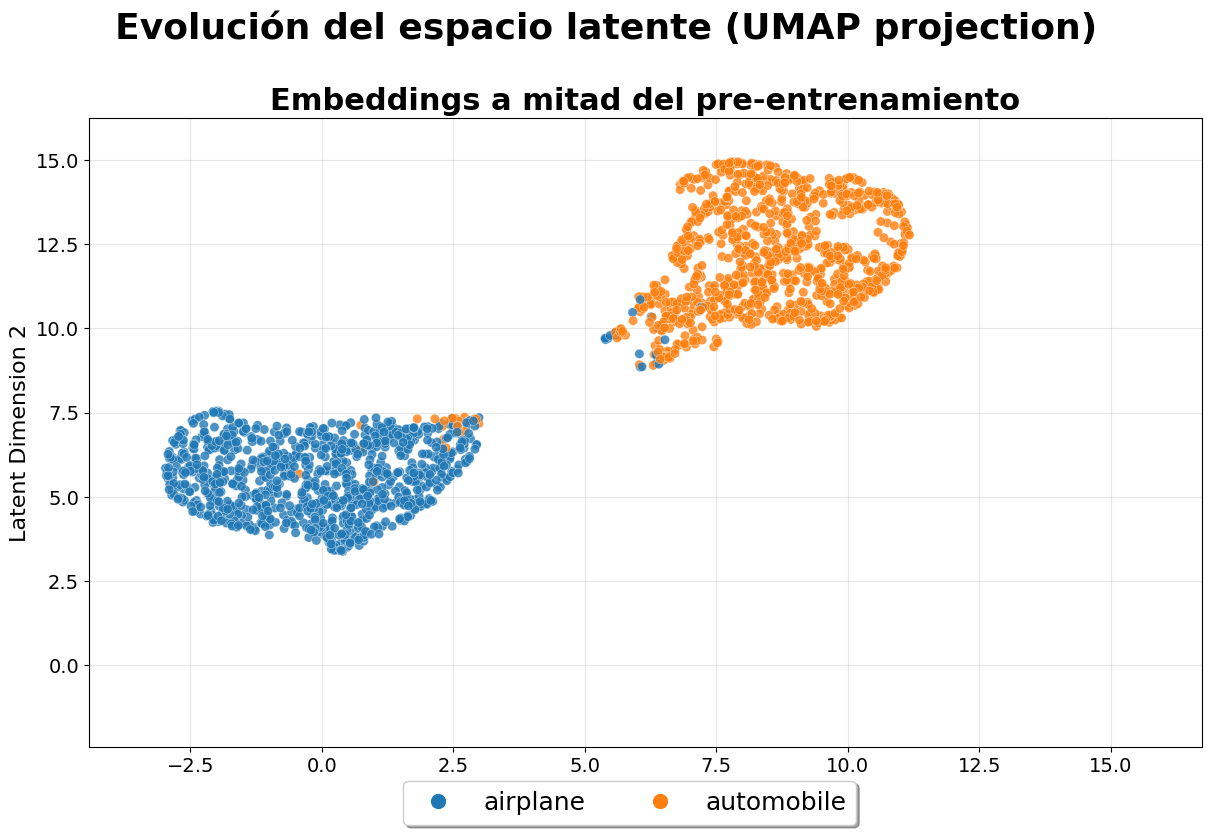

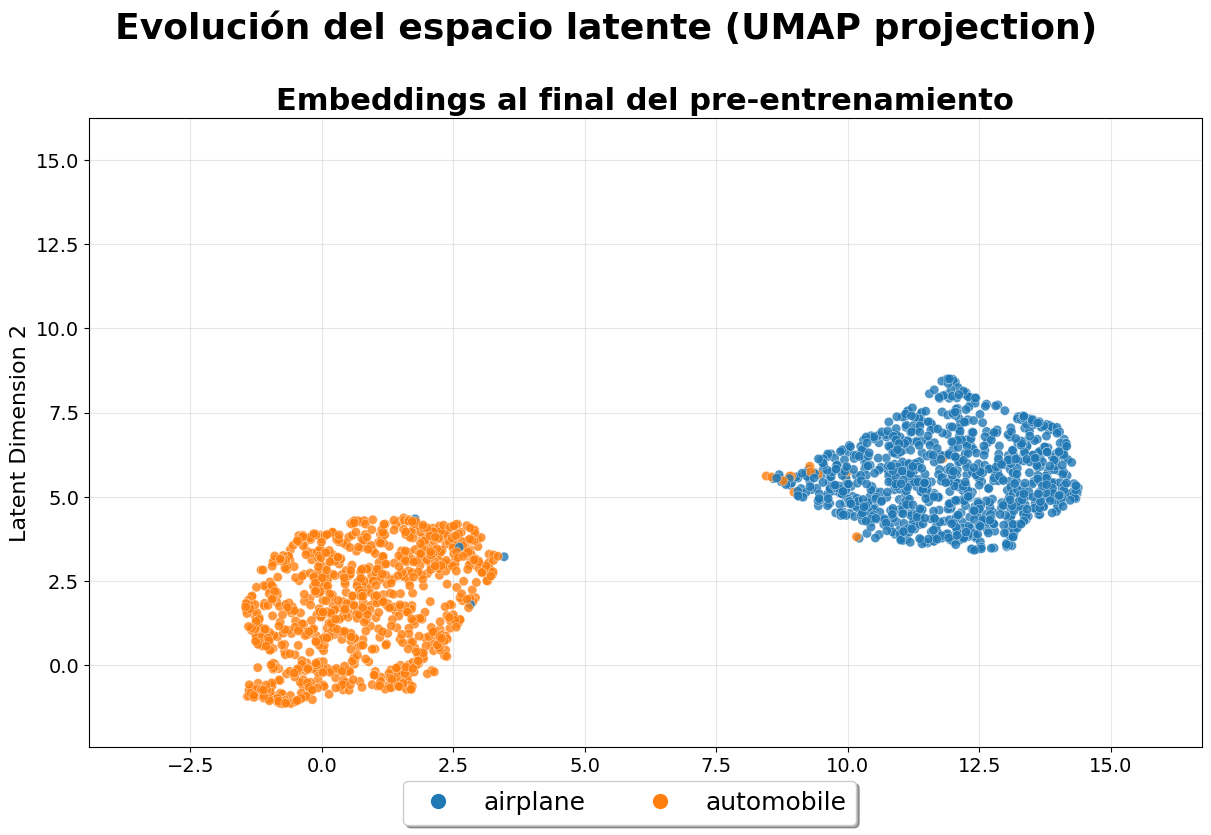

In [6]:
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=int(cfg.training.seed),
    reduction_method="umap",
    save_path=Path(cfg.outputs.root) / "imgs" / "embedding_snapshots_umap",
)

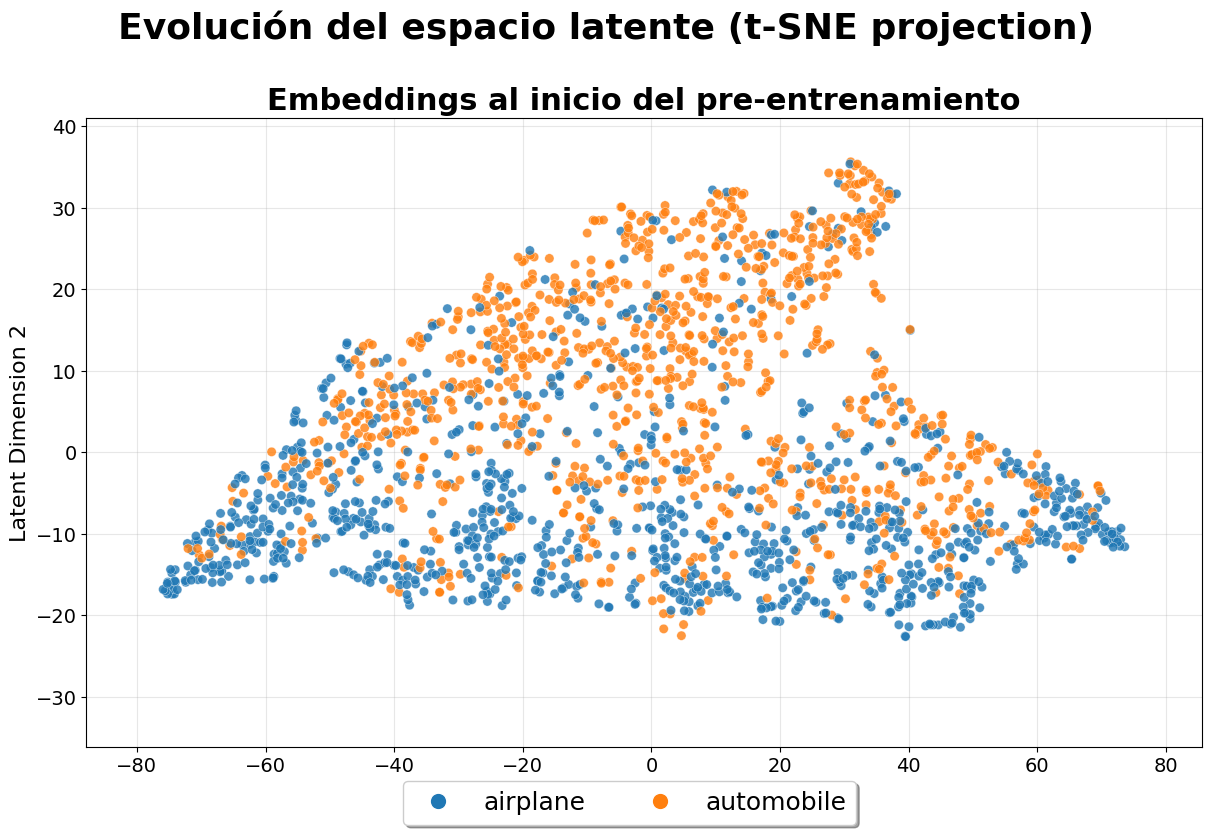

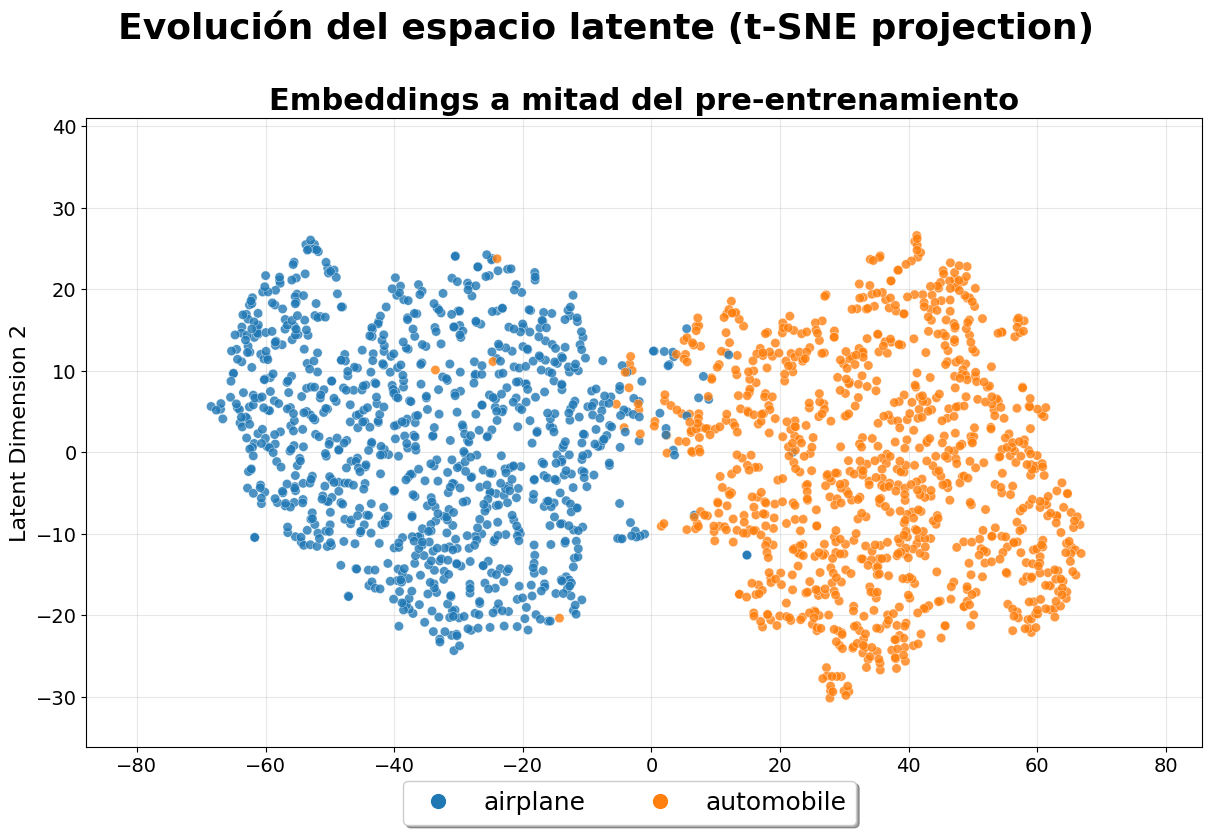

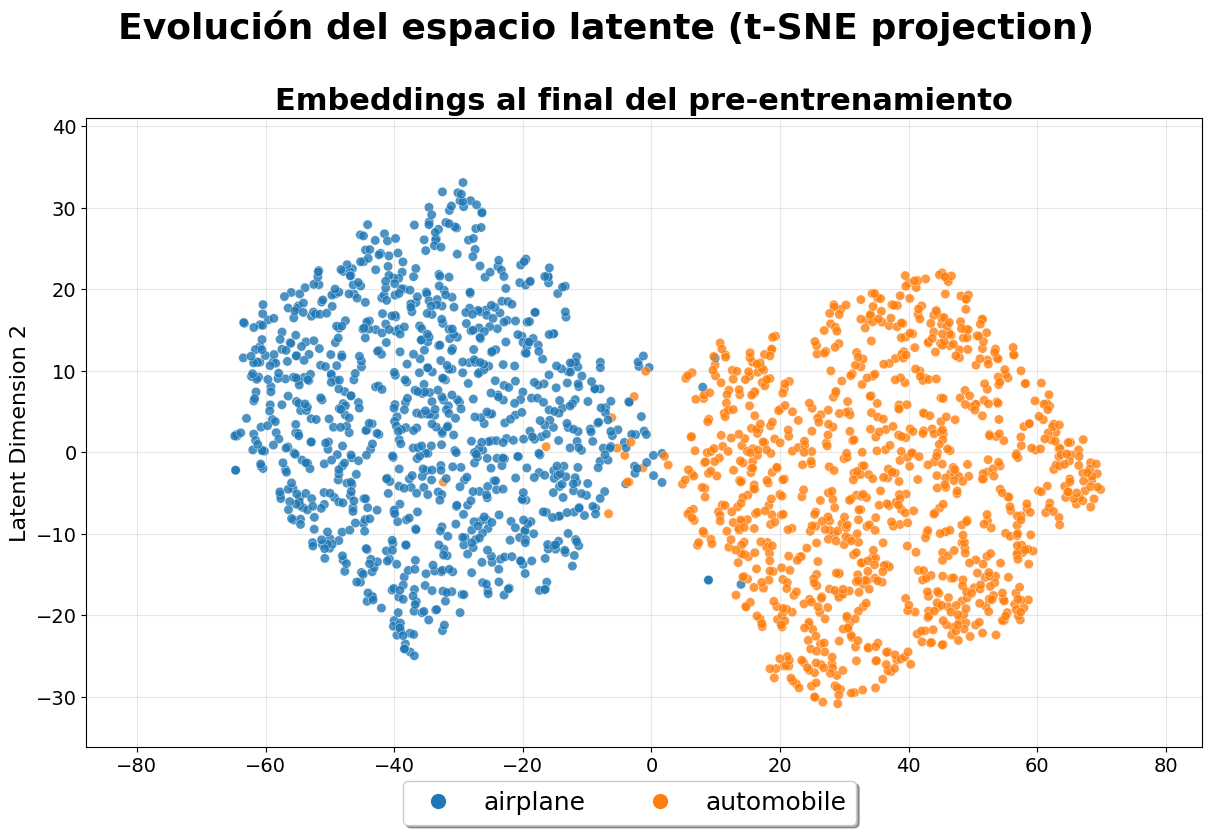

In [7]:
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=int(cfg.training.seed),
    reduction_method="tsne",
    save_path=Path(cfg.outputs.root) / "imgs" / "embedding_snapshots_tsne",
)

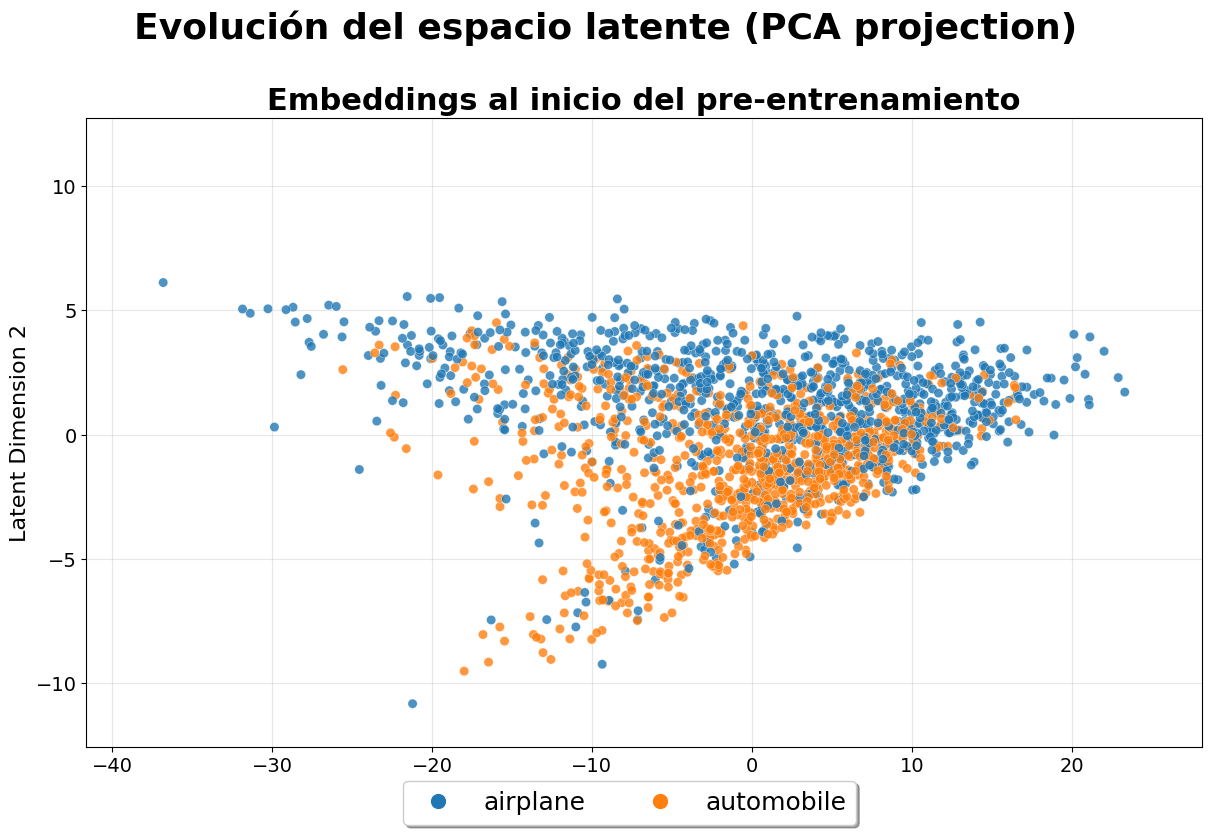

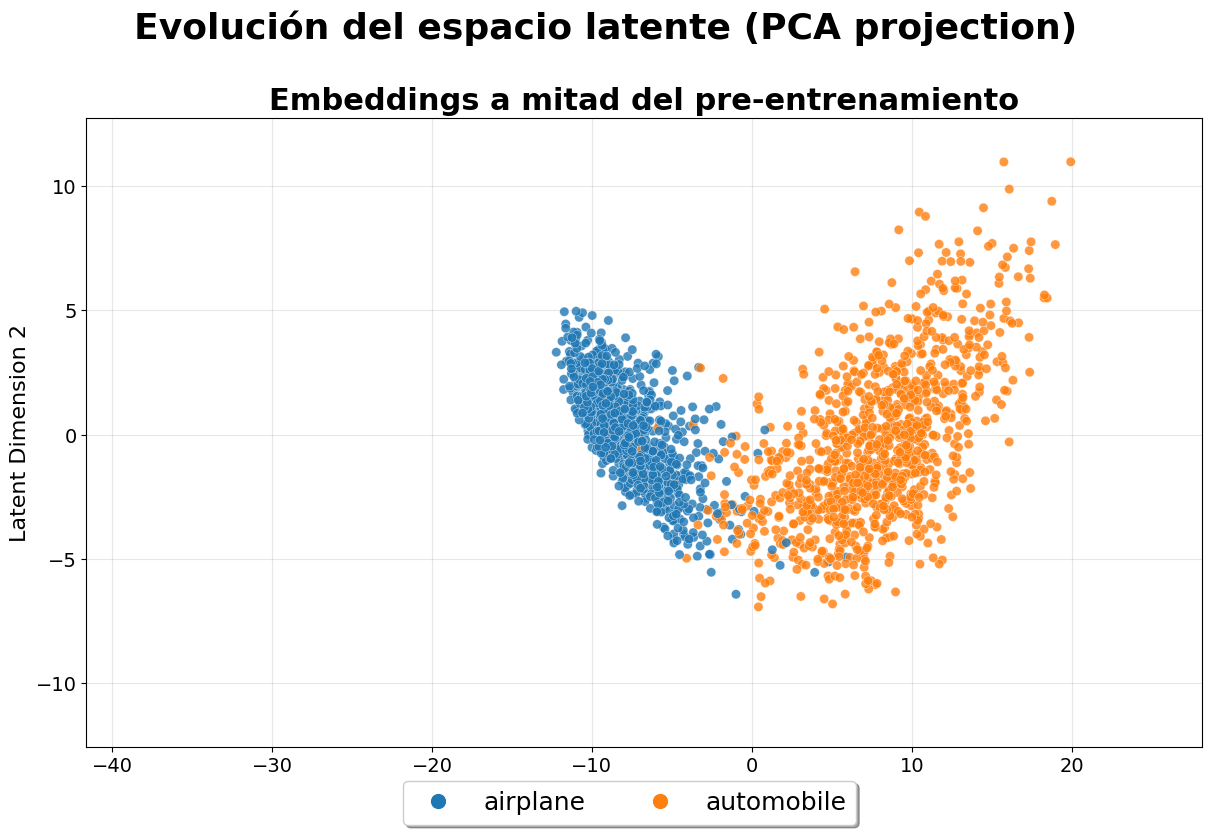

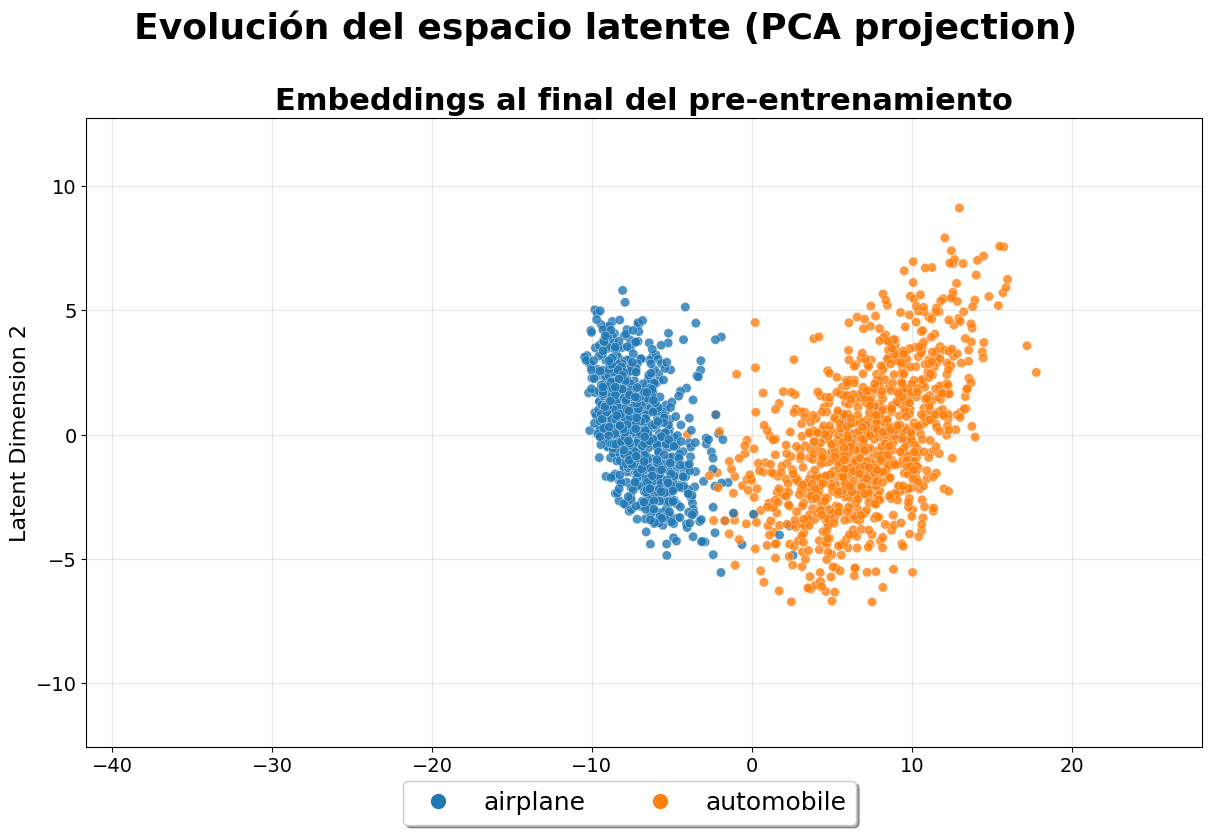

In [8]:
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=int(cfg.training.seed),
    reduction_method="pca",
    save_path=Path(cfg.outputs.root) / "imgs" / "embedding_snapshots_pca",
)

## **Entrenamiento de cabeza de clasificación lineal**

In [9]:
label_mapper_task0 = LabelMapper(task_classes=task0_classes)
task0_train_linear = seq_builder.get_task_dataset(
    task_id=0, train=True, transform=eval_transform, target_transform=label_mapper_task0
)
task0_test_linear = seq_builder.get_task_dataset(
    task_id=0, train=False, transform=eval_transform, target_transform=label_mapper_task0
)

task0_train_linear_loader = DataLoader(
    task0_train_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    **dataloader_kwargs,
)
task0_test_linear_loader = DataLoader(
    task0_test_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

linear_head = nn.Linear(feat_dim, len(task0_classes)).to(device)
linear_ckpt = ckpt("task0_linear_eval.pt")

if linear_ckpt.exists():
    payload = load_checkpoint(linear_ckpt, map_location=device)
    linear_head.load_state_dict(payload["linear_head"])
    linear_history = payload["history"]
    task0_best_test_accuracy = payload["best_test_acc"]
    print(f"Loaded checkpoint: {linear_ckpt}")
else:
    linear_history, task0_best_test_accuracy = train_linear_head(
        backbone=supcon_model.backbone,
        linear_head=linear_head,
        train_loader=task0_train_linear_loader,
        test_loader=task0_test_linear_loader,
        device=device,
        epochs=int(cfg.linear_eval.epochs),
        lr=float(cfg.linear_eval.lr),
        scheduler_milestones=list(cfg.linear_eval.milestones),
        scheduler_gamma=float(cfg.linear_eval.gamma),
        report_best=True,
    )
    save_checkpoint(
        linear_ckpt,
        {
            "linear_head": linear_head.state_dict(),
            "history": linear_history,
            "best_test_acc": task0_best_test_accuracy,
        },
    )
    print(f"Saved checkpoint: {linear_ckpt}")

Loaded checkpoint: outputs/checkpoints/task0_linear_eval.pt


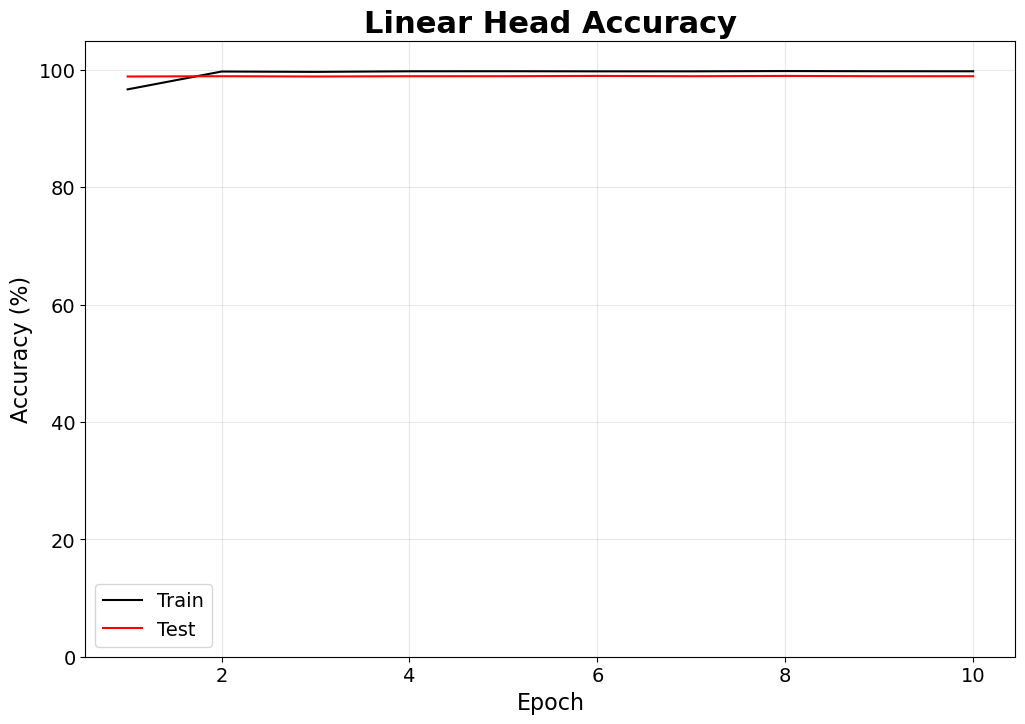

In [10]:
plot_linear_history(linear_history, save_path=Path(cfg.outputs.root) / "imgs" / "linear_eval_accuracy.png")

## **Bootstrap del protocolo CL (Task 0 pre-entrenada)**

In [11]:
from copy import deepcopy

protocol_task_ids = [int(t) for t in cfg.protocol.task_ids]
if 0 in protocol_task_ids:
    raise ValueError("Protocol task_ids must exclude Task 0 in from_task0_pretrained mode")

task0_baseline_acc = float(linear_history["test_acc"][-1])
task0_baseline = task0_baseline_payload(
    task0_acc=task0_baseline_acc,
    n_tasks=int(cfg.data.n_tasks),
    task0_id=0,
)

initial_seen_task_ids = [0]
initial_classifier = build_initial_classifier_from_linear_head(
    backbone=supcon_model.backbone,
    feat_dim=feat_dim,
    num_classes=len(CIFAR10_CLASSES),
    linear_head=linear_head,
    task0_classes=task0_classes,
    device=device,
)

task0_buffer = build_task0_replay_buffer(
    train_loader=task_train_loaders[0],
    capacity=int(cfg.data.buffer_size),
    seed=int(cfg.training.seed),
)

initial_ewc_terms = build_task0_ewc_terms(
    model=initial_classifier,
    train_loader_task0=task_train_loaders[0],
    device=device,
    fisher_max_batches=int(cfg.ewc.fisher_max_batches),
    fisher_loss_mode=str(cfg.ewc.fisher_loss_mode),
)

lwf_initial_teacher = deepcopy(initial_classifier).to(device).eval()
for p in lwf_initial_teacher.parameters():
    p.requires_grad = False

co2l_train_loaders = {}
for task_id in range(int(cfg.data.n_tasks)):
    task_raw_ds = seq_builder.get_task_dataset(task_id=task_id, train=True, transform=None)
    task_contrastive_ds = ContrastiveTaskDataset(
        task_dataset=task_raw_ds,
        two_crop_transform=TwoCropTransform(supcon_train_transform),
    )
    co2l_train_loaders[task_id] = DataLoader(
        task_contrastive_ds,
        batch_size=int(cfg.co2l.batch_size),
        shuffle=True,
        drop_last=True,
        **dataloader_kwargs,
    )

co2l_initial_model = SupConNetwork(
    backbone=deepcopy(supcon_model.backbone),
    feat_dim=feat_dim,
    proj_dim=int(cfg.supcon.proj_dim),
).to(device)
co2l_initial_model.load_state_dict(supcon_model.state_dict())
co2l_initial_past_model = deepcopy(co2l_initial_model).to(device).eval()
for p in co2l_initial_past_model.parameters():
    p.requires_grad = False

expected_task_id_sequence = [0.0] + [float(t) for t in protocol_task_ids]

def history_matches_protocol(history: dict) -> bool:
    if not isinstance(history, dict):
        return False
    task_id = history.get("task_id")
    if not isinstance(task_id, list):
        return False
    try:
        parsed_ids = [float(x) for x in task_id]
    except Exception:
        return False
    if parsed_ids != expected_task_id_sequence:
        return False
    required = [
        "class_il",
        "task_il",
        "taskwise_class_il_matrix",
        "taskwise_task_il_matrix",
    ]
    for key in required:
        value = history.get(key)
        if not isinstance(value, list) or len(value) != len(expected_task_id_sequence):
            return False
    return True

print(f"Protocol task ids: {protocol_task_ids}")

Protocol task ids: [1, 2, 3, 4]


## ***Fine-Tuning Naive ($Baseline$)***

In [12]:
naive_ckpt = ckpt("naive_seq_cifar10.pt")

need_train_naive = True
if naive_ckpt.exists() and not FORCE_RETRAIN:
    payload = load_checkpoint(naive_ckpt, map_location=device)
    candidate_history = payload.get("history", {})
    if history_matches_protocol(candidate_history):
        naive_history = candidate_history
        naive_model = deepcopy(initial_classifier).to(device)
        naive_model.load_state_dict(payload['model'])
        print(f"Loaded checkpoint: {naive_ckpt}")
        need_train_naive = False
    else:
        print("Naive checkpoint incompatible with from_task0_pretrained protocol. Re-training and overwriting.")

if need_train_naive:
    naive_model, naive_history = train_naive_finetuning(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.finetuning.epochs_per_task),
        lr=float(cfg.finetuning.lr),
        momentum=float(cfg.finetuning.momentum),
        weight_decay=float(cfg.finetuning.weight_decay),
        task_ids=protocol_task_ids,
        initial_model=initial_classifier,
        initial_seen_task_ids=initial_seen_task_ids,
        baseline_payload=task0_baseline,
        verbose=True,
    )
    save_checkpoint(
        naive_ckpt,
        {
            "model": naive_model.state_dict(),
            "history": naive_history,
        },
    )
    print(f"Saved checkpoint: {naive_ckpt}")

Loaded checkpoint: outputs/checkpoints/naive_seq_cifar10.pt


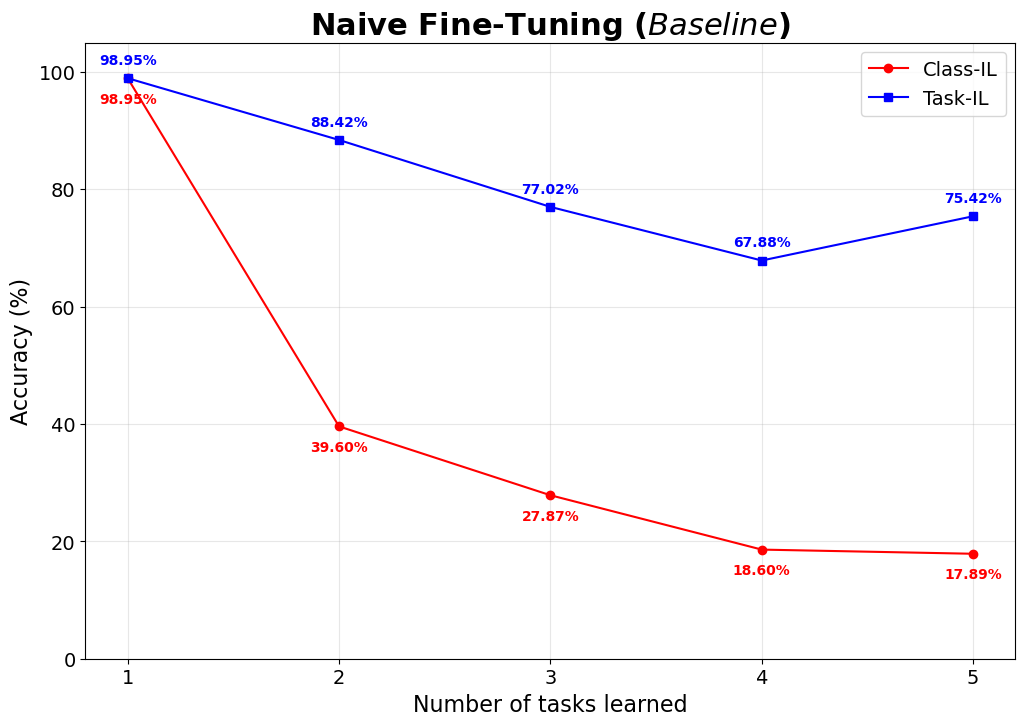

In [13]:
plot_cl_metrics(naive_history, title=r"Naive Fine-Tuning ($Baseline$)", save_path=Path(cfg.outputs.root) / "imgs" / "naive_cl_metrics.png")

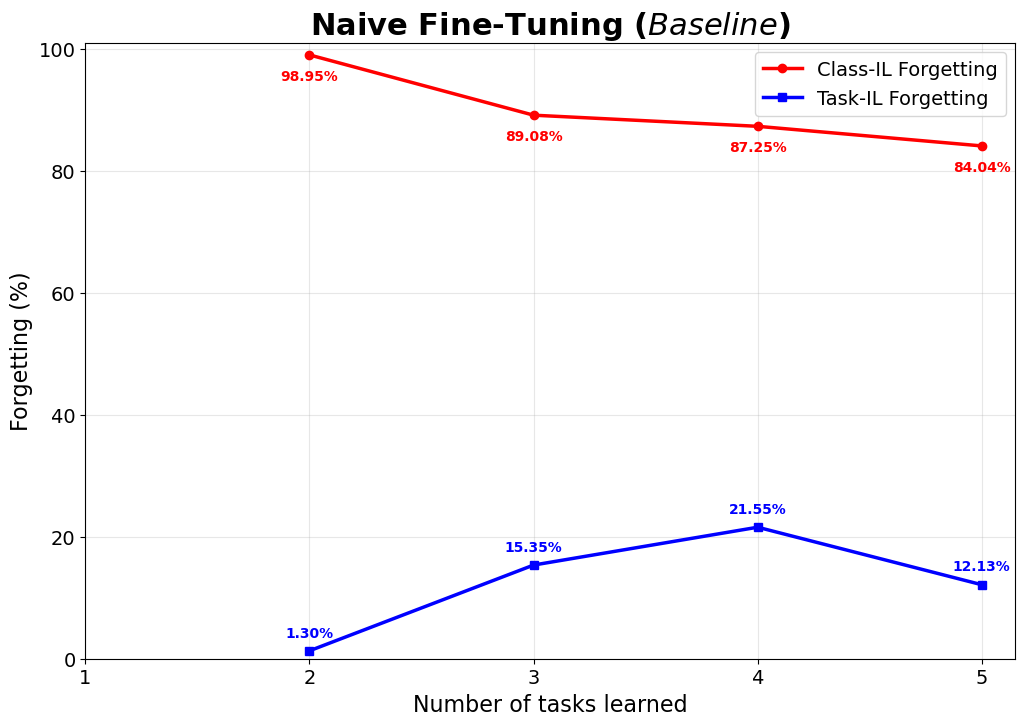

In [14]:
plot_forgetting_metrics(naive_history, title=r"Naive Fine-Tuning ($Baseline$)", save_path=Path(cfg.outputs.root) / "imgs" / "naive_forgetting_metrics.png")

## ***Elastic Weight Consolidation ($EWC$)***

In [15]:
ewc_ckpt = ckpt("ewc_seq_cifar10.pt")

need_train_ewc = True
if ewc_ckpt.exists() and not FORCE_RETRAIN:
    payload = load_checkpoint(ewc_ckpt, map_location=device)
    candidate_history = payload.get("history", {})
    if history_matches_protocol(candidate_history):
        ewc_history = candidate_history
        ewc_model = deepcopy(initial_classifier).to(device)
        ewc_model.load_state_dict(payload['model'])
        print(f"Loaded checkpoint: {ewc_ckpt}")
        need_train_ewc = False
    else:
        print("EWC checkpoint incompatible with from_task0_pretrained protocol. Re-training and overwriting.")

if need_train_ewc:
    ewc_model, ewc_history = train_ewc(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.ewc.epochs_per_task),
        lr=float(cfg.ewc.lr),
        momentum=float(cfg.ewc.momentum),
        weight_decay=float(cfg.ewc.weight_decay),
        ewc_lambda=float(cfg.ewc.lambda_ewc),
        fisher_max_batches=int(cfg.ewc.fisher_max_batches),
        fisher_loss_mode=str(cfg.ewc.fisher_loss_mode),
        task_ids=protocol_task_ids,
        initial_model=initial_classifier,
        initial_seen_task_ids=initial_seen_task_ids,
        initial_ewc_terms=initial_ewc_terms,
        baseline_payload=task0_baseline,
        verbose=True,
    )
    save_checkpoint(
        ewc_ckpt,
        {
            "model": ewc_model.state_dict(),
            "history": ewc_history,
        },
    )
    print(f"Saved checkpoint: {ewc_ckpt}")


Loaded checkpoint: outputs/checkpoints/ewc_seq_cifar10.pt


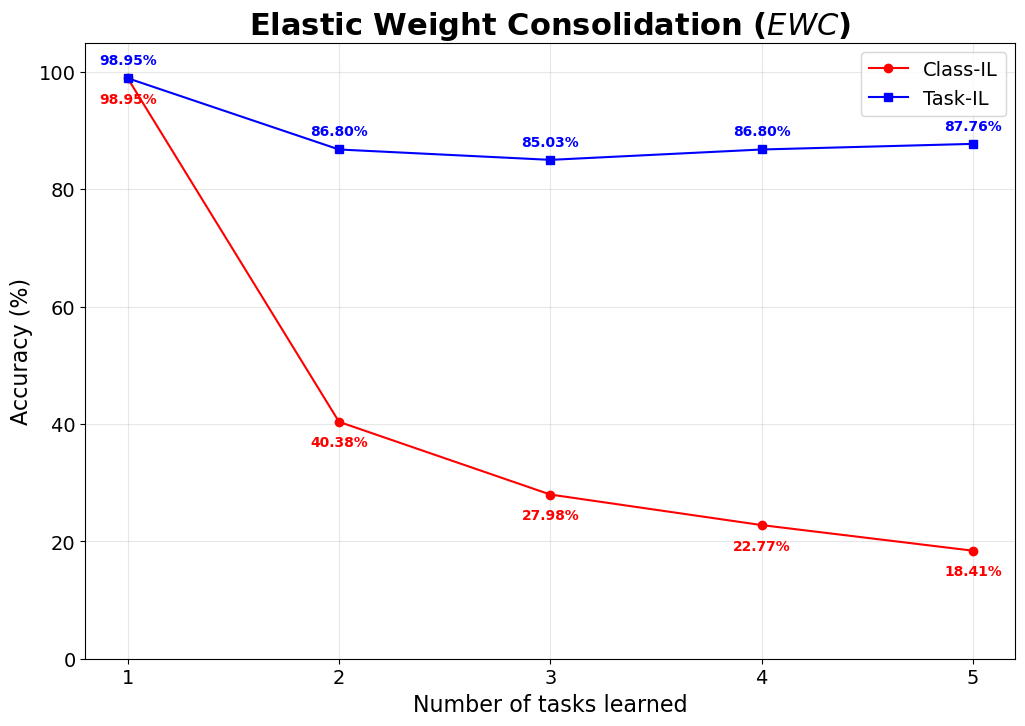

In [16]:
plot_cl_metrics(ewc_history, title=r"Elastic Weight Consolidation ($EWC$)", save_path=Path(cfg.outputs.root) / "imgs" / "ewc_cl_metrics.png")

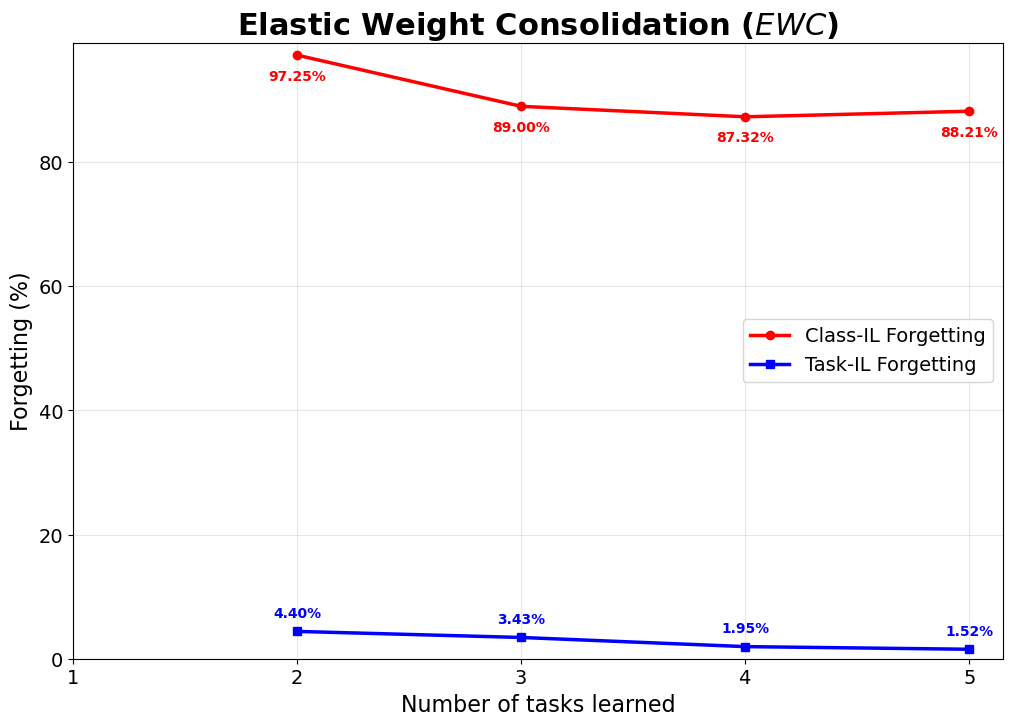

In [17]:
plot_forgetting_metrics(ewc_history, title=r"Elastic Weight Consolidation ($EWC$)", save_path=Path(cfg.outputs.root) / "imgs" / "ewc_forgetting_metrics.png")

## ***Learning without Forgetting ($LwF$)***

In [18]:
lwf_ckpt = ckpt("lwf_seq_cifar10.pt")

lwf_resume_teacher = lwf_initial_teacher
need_train_lwf = True
if lwf_ckpt.exists() and not FORCE_RETRAIN:
    payload = load_checkpoint(lwf_ckpt, map_location=device)
    teacher_state = payload.get("teacher_model")
    if teacher_state is not None:
        lwf_resume_teacher = deepcopy(initial_classifier).to(device).eval()
        lwf_resume_teacher.load_state_dict(teacher_state)
        for p in lwf_resume_teacher.parameters():
            p.requires_grad = False
    candidate_history = payload.get("history", {})
    if history_matches_protocol(candidate_history):
        lwf_history = candidate_history
        lwf_model = deepcopy(initial_classifier).to(device)
        lwf_model.load_state_dict(payload['model'])
        print(f"Loaded checkpoint: {lwf_ckpt}")     
        need_train_lwf = False
    else:
        print("LwF checkpoint incompatible with from_task0_pretrained protocol. Re-training and overwriting.")

if need_train_lwf:
    lwf_model, lwf_history = train_lwf(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.lwf.epochs_per_task),
        lr=float(cfg.lwf.lr),
        momentum=float(cfg.lwf.momentum),
        weight_decay=float(cfg.lwf.weight_decay),
        temperature=float(cfg.lwf.temperature),
        alpha=float(cfg.lwf.alpha),
        task_ids=protocol_task_ids,
        initial_model=initial_classifier,
        initial_seen_task_ids=initial_seen_task_ids,
        initial_teacher_model=lwf_resume_teacher,
        baseline_payload=task0_baseline,
        verbose=True,
    )
    save_checkpoint(
        lwf_ckpt,
        {
            "model": lwf_model.state_dict(),
            "history": lwf_history,
            "teacher_model": deepcopy(lwf_model).state_dict(),
        },
    )
    print(f"Saved checkpoint: {lwf_ckpt}")

Loaded checkpoint: outputs/checkpoints/lwf_seq_cifar10.pt


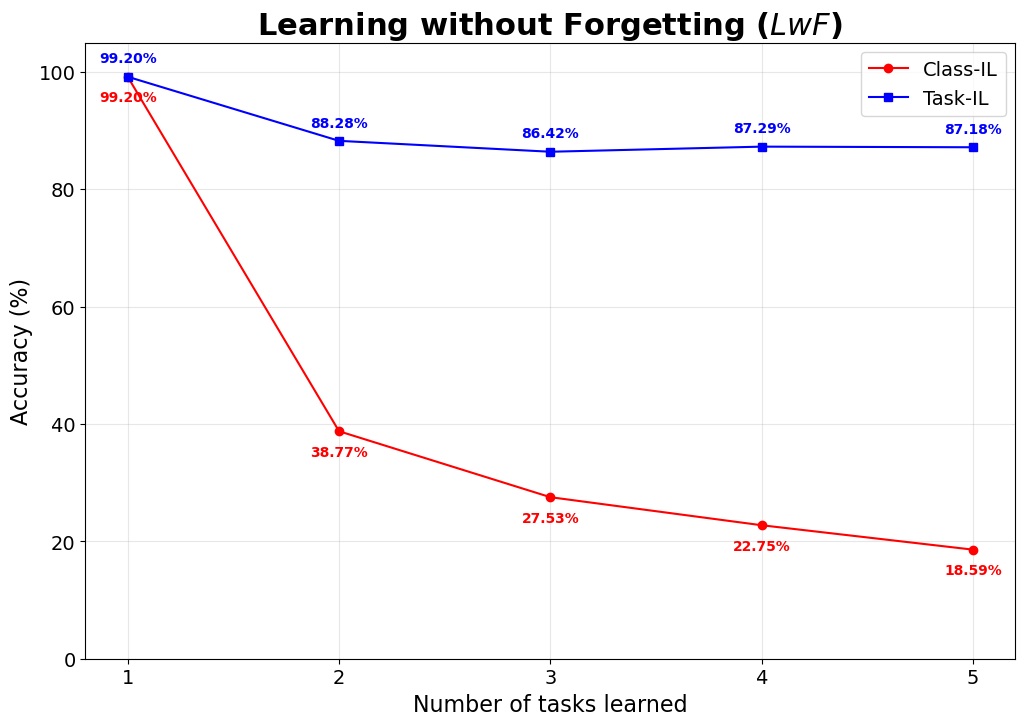

In [19]:
plot_cl_metrics(lwf_history, title=r"Learning without Forgetting ($LwF$)", save_path=Path(cfg.outputs.root) / "imgs" / "lwf_cl_metrics.png")

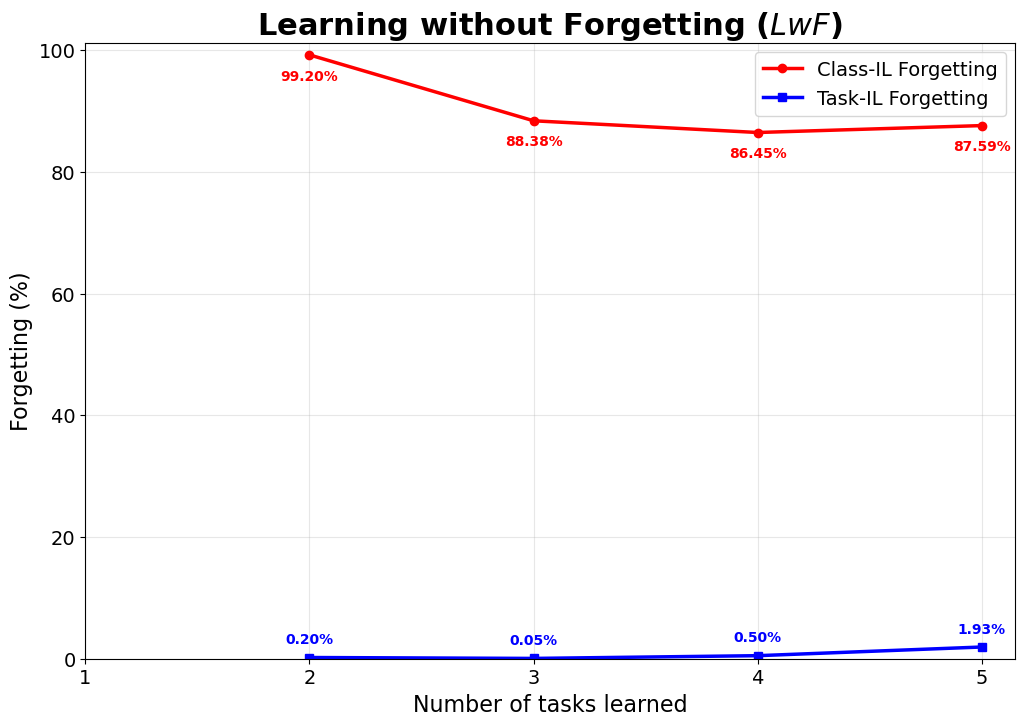

In [20]:
plot_forgetting_metrics(lwf_history, title=r"Learning without Forgetting ($LwF$)", save_path=Path(cfg.outputs.root) / "imgs" / "lwf_forgetting_metrics.png")

## ***Contrastive Continual Learning ($Co^2L$)***

In [21]:
co2l_ckpt = ckpt("co2l_seq_cifar10.pt")

need_train_co2l = True
if co2l_ckpt.exists() and not FORCE_RETRAIN:
    payload = load_checkpoint(co2l_ckpt, map_location=device)
    candidate_history = payload.get("history", {})
    if history_matches_protocol(candidate_history):
        co2l_history = candidate_history
        co2l_model = deepcopy(co2l_initial_model).to(device)
        co2l_model.load_state_dict(payload['model'])
        print(f"Loaded checkpoint: {co2l_ckpt}")
        need_train_co2l = False
    else:
        print("Co2L checkpoint incompatible with from_task0_pretrained protocol. Re-training and overwriting.")

if need_train_co2l:
    co2l_model, co2l_history = train_co2l(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=co2l_train_loaders,
        train_loaders_eval=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        proj_dim=int(cfg.supcon.proj_dim),
        buffer_size=int(cfg.data.buffer_size),
        lr=float(cfg.co2l.lr),
        momentum=float(cfg.co2l.momentum),
        weight_decay=float(cfg.co2l.weight_decay),
        temperature=float(cfg.co2l.temperature),
        kappa=float(cfg.co2l.kappa),
        kappa_star=float(cfg.co2l.kappa_star),
        lambda_ird=float(cfg.co2l.lambda_ird),
        warmup_epochs=int(cfg.co2l.warmup_epochs),
        epochs_task0=int(cfg.co2l.epochs_task0),
        epochs_per_task=int(cfg.co2l.epochs_per_task),
        eval_linear_epochs=int(cfg.co2l.eval_linear_epochs),
        eval_linear_lr=float(cfg.co2l.eval_linear_lr),
        eval_linear_milestones=list(cfg.co2l.eval_linear_milestones),
        eval_linear_gamma=float(cfg.co2l.eval_linear_gamma),
        task_ids=protocol_task_ids,
        seed=int(cfg.training.seed),
        max_replay_batch_size=int(cfg.co2l.max_replay_batch_size),
        initial_model=co2l_initial_model,
        initial_seen_task_ids=initial_seen_task_ids,
        initial_past_model=co2l_initial_past_model,
        initial_buffer=task0_buffer,
        baseline_payload=task0_baseline,
        verbose=True,
    )
    save_checkpoint(
        co2l_ckpt,
        {
            "model": co2l_model.state_dict(),
            "history": co2l_history,
        },
    )
    print(f"Saved checkpoint: {co2l_ckpt}")

Loaded checkpoint: outputs/checkpoints/co2l_seq_cifar10.pt


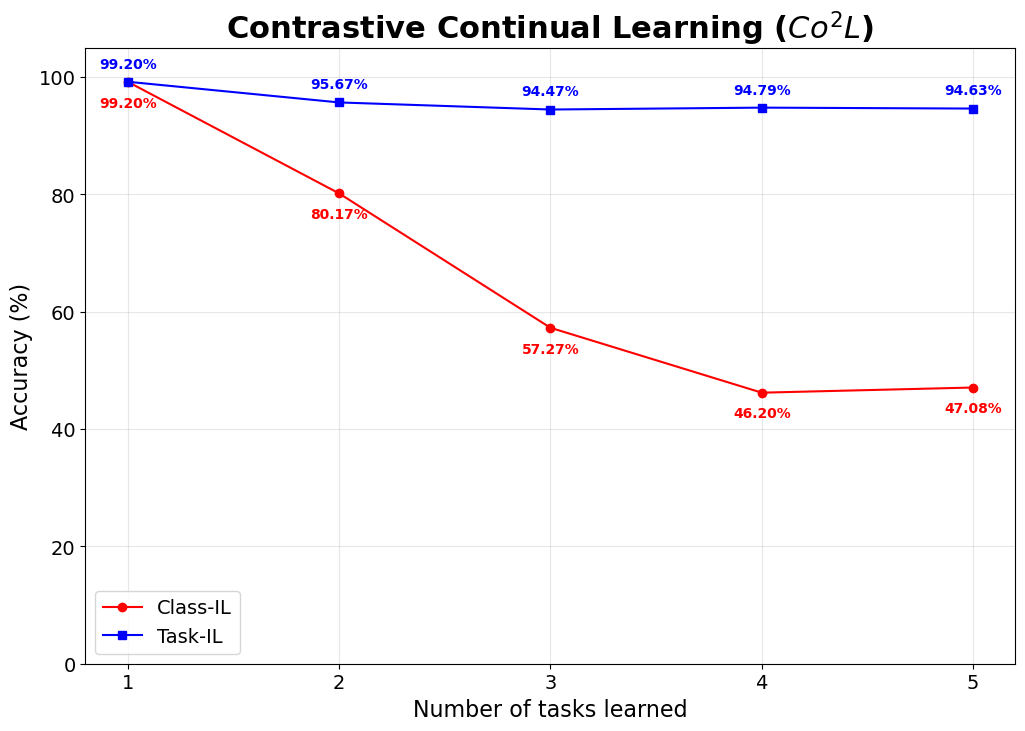

In [22]:
plot_cl_metrics(co2l_history, title=r"Contrastive Continual Learning ($Co^2L$)", save_path=Path(cfg.outputs.root) / "imgs" / "co2l_cl_metrics.png")

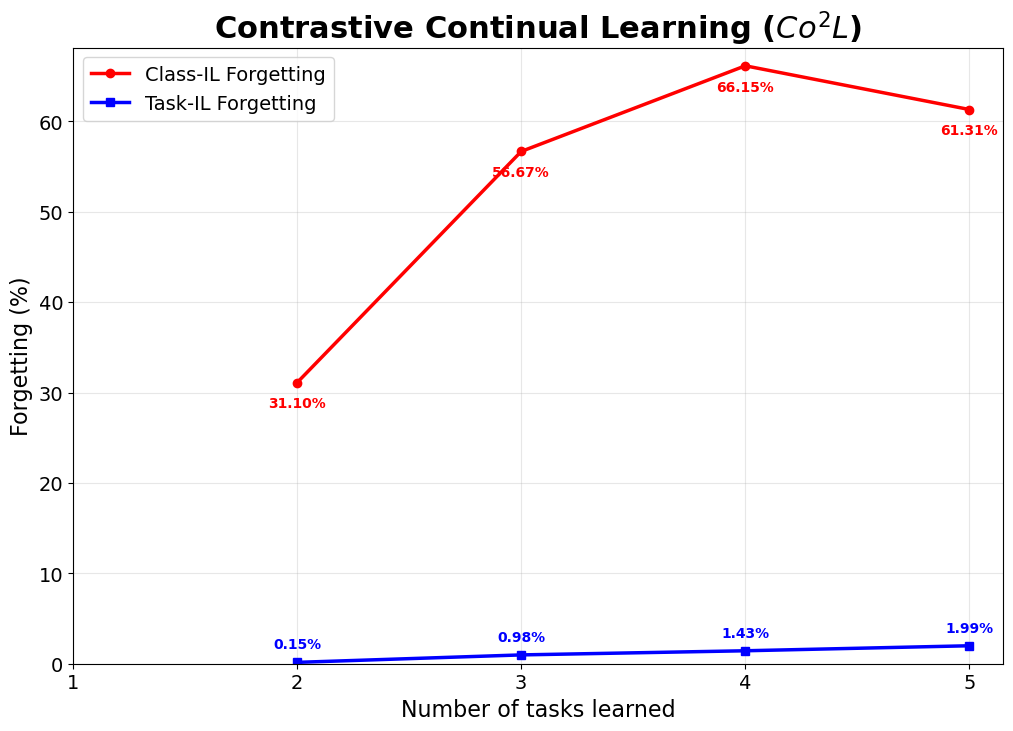

In [23]:
plot_forgetting_metrics(co2l_history, title=r"Contrastive Continual Learning ($Co^2L$)", save_path=Path(cfg.outputs.root) / "imgs" / "co2l_forgetting_metrics.png")

## ***Experience Replay with Asymmetric Cross-Entropy ($ER-ACE$)***

In [24]:
er_ace_ckpt = ckpt("er_ace_seq_cifar10.pt")

need_train_erace = True
if er_ace_ckpt.exists() and not FORCE_RETRAIN:
    payload = load_checkpoint(er_ace_ckpt, map_location=device)
    candidate_history = payload.get("history", {})
    if history_matches_protocol(candidate_history):
        er_ace_history = candidate_history
        er_ace_model = deepcopy(initial_classifier).to(device)
        er_ace_model.load_state_dict(payload['model'])
        print(f"Loaded checkpoint: {er_ace_ckpt}")
        need_train_erace = False
    else:
        print("ER-ACE checkpoint incompatible with from_task0_pretrained protocol. Re-training and overwriting.")

if need_train_erace:
    er_ace_model, er_ace_history = train_er_ace(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.er_ace.epochs_per_task),
        lr=float(cfg.er_ace.lr),
        momentum=float(cfg.er_ace.momentum),
        weight_decay=float(cfg.er_ace.weight_decay),
        buffer_size=int(cfg.data.buffer_size),
        replay_batch_size=int(cfg.er_ace.replay_batch_size),
        incoming_weight=float(cfg.er_ace.incoming_weight),
        replay_weight=float(cfg.er_ace.replay_weight),
        task_ids=protocol_task_ids,
        seed=int(cfg.training.seed),
        initial_model=initial_classifier,
        initial_seen_task_ids=initial_seen_task_ids,
        initial_buffer=task0_buffer,
        baseline_payload=task0_baseline,
        verbose=True,
    )
    save_checkpoint(
        er_ace_ckpt,
        {
            "model": er_ace_model.state_dict(),
            "history": er_ace_history,
        },
    )
    print(f"Saved checkpoint: {er_ace_ckpt}")

Loaded checkpoint: outputs/checkpoints/er_ace_seq_cifar10.pt


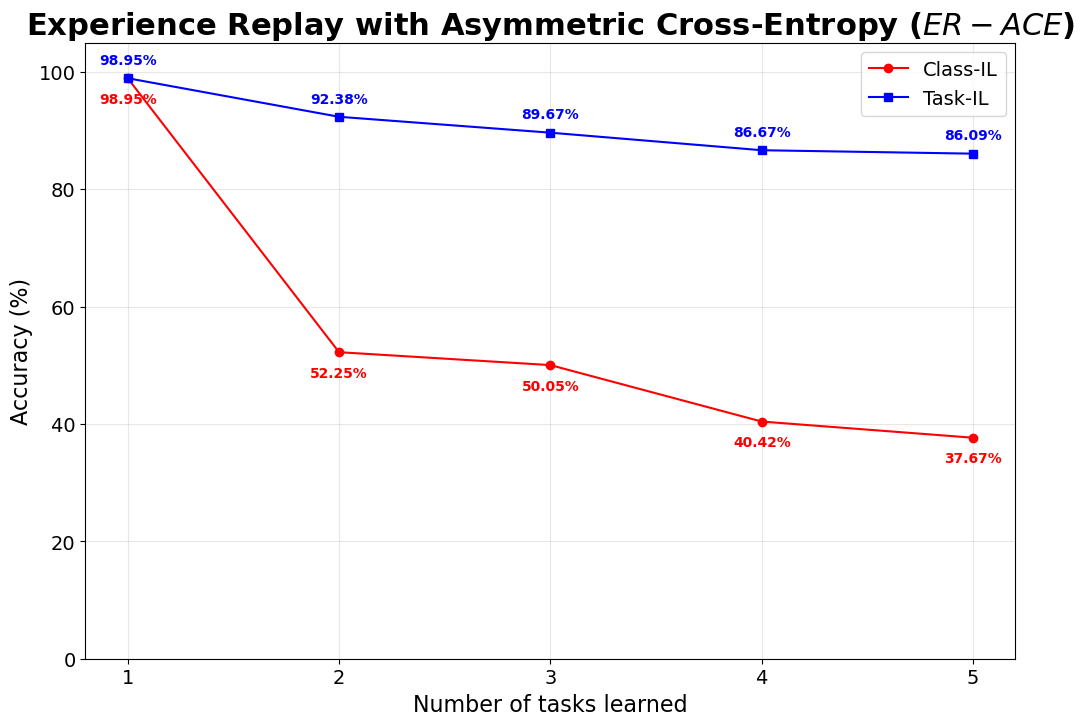

In [25]:
plot_cl_metrics(er_ace_history, title=r"Experience Replay with Asymmetric Cross-Entropy ($ER-ACE$)", save_path=Path(cfg.outputs.root) / "imgs" / "er_ace_cl_metrics.png")

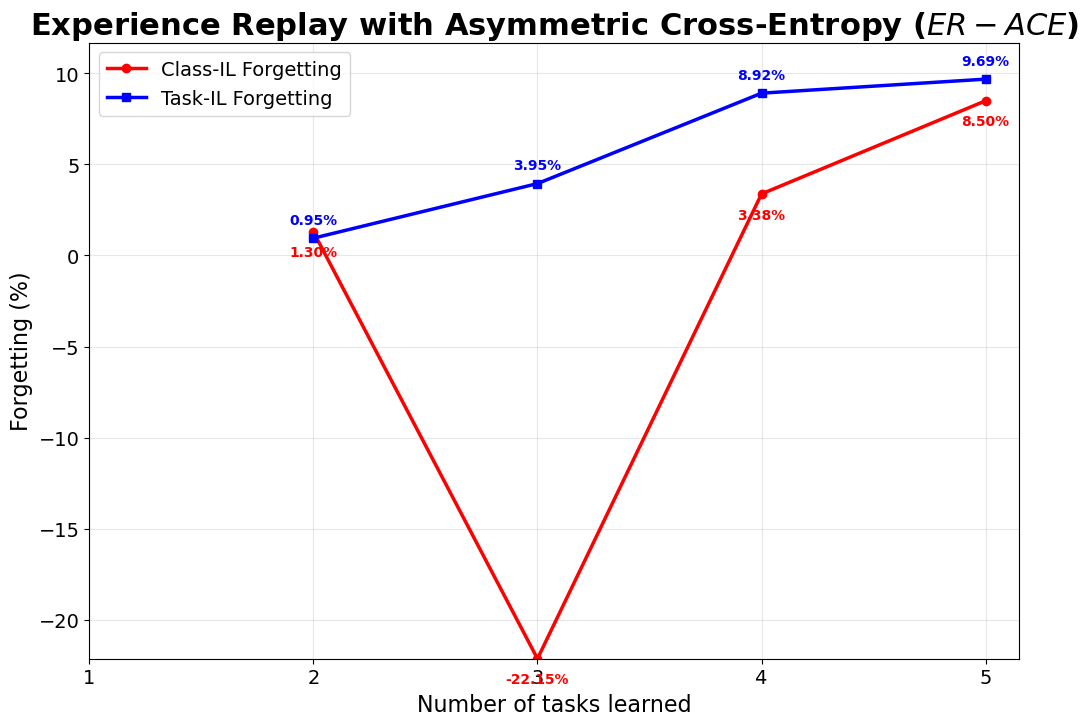

In [26]:
plot_forgetting_metrics(er_ace_history, title=r"Experience Replay with Asymmetric Cross-Entropy ($ER-ACE$)", save_path=Path(cfg.outputs.root) / "imgs" / "er_ace_forgetting_metrics.png")

## **Comparativa final de metodos**

Generando comparativa completa para: F-T Naive, EWC, LwF, Co2L, ER-ACE

--- Resumen de Métricas Finales ---


,Final Class-IL (%),Final Task-IL (%),Forgetting (Class),BWT (Class),Forgetting (Task),BWT (Task)
Método,,,,,,
F-T Naive,17.89,75.42,84.0375,-84.0375,12.1250,-12.1250
EWC,18.41,87.76,88.2125,-88.2125,1.5250,-1.5250
LwF,18.59,87.18,87.5875,-87.5875,1.9250,-1.8500
Co2L,47.08,94.63,61.3125,-61.3125,1.9875,-1.9875
ER-ACE,37.67,86.09,8.5000,20.6000,9.6875,-9.6875



Generando gráficos de evolución...


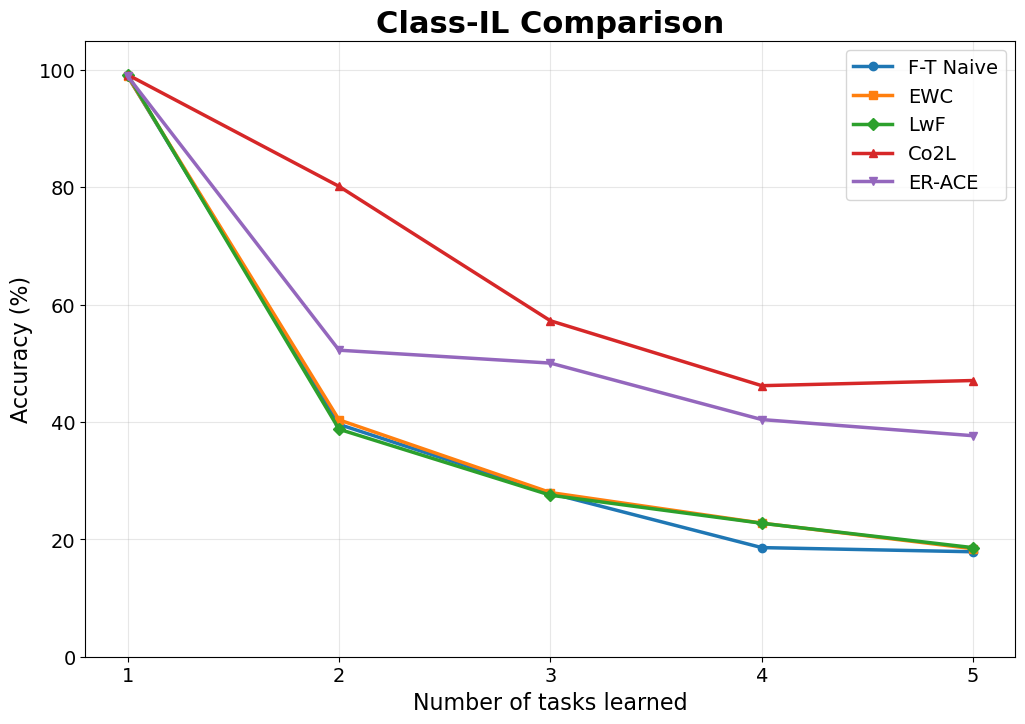

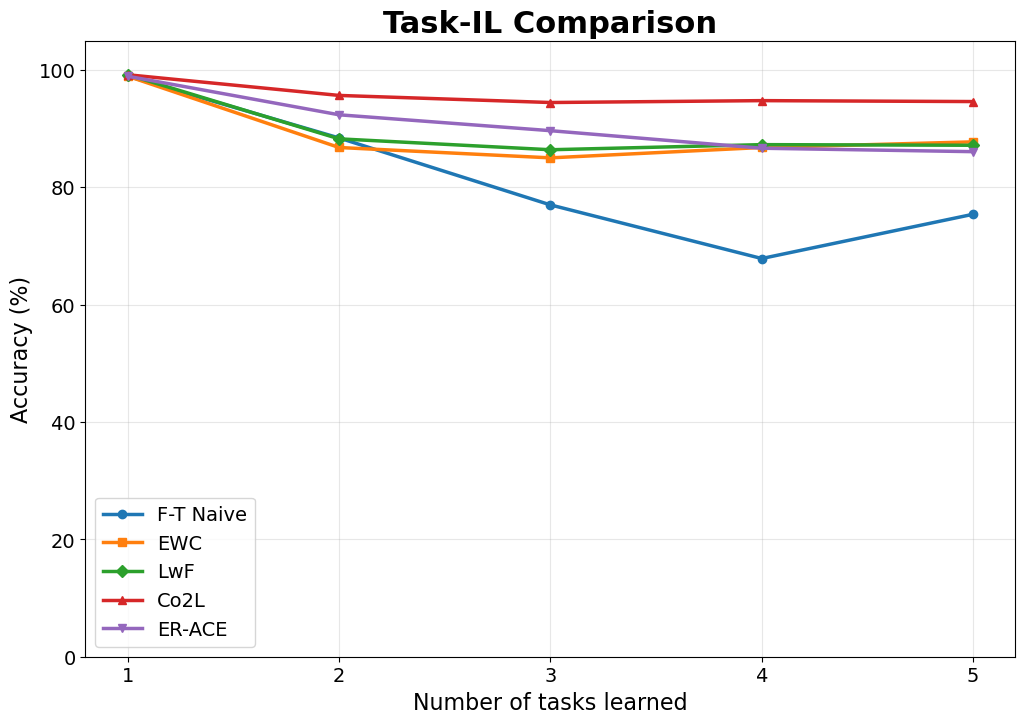

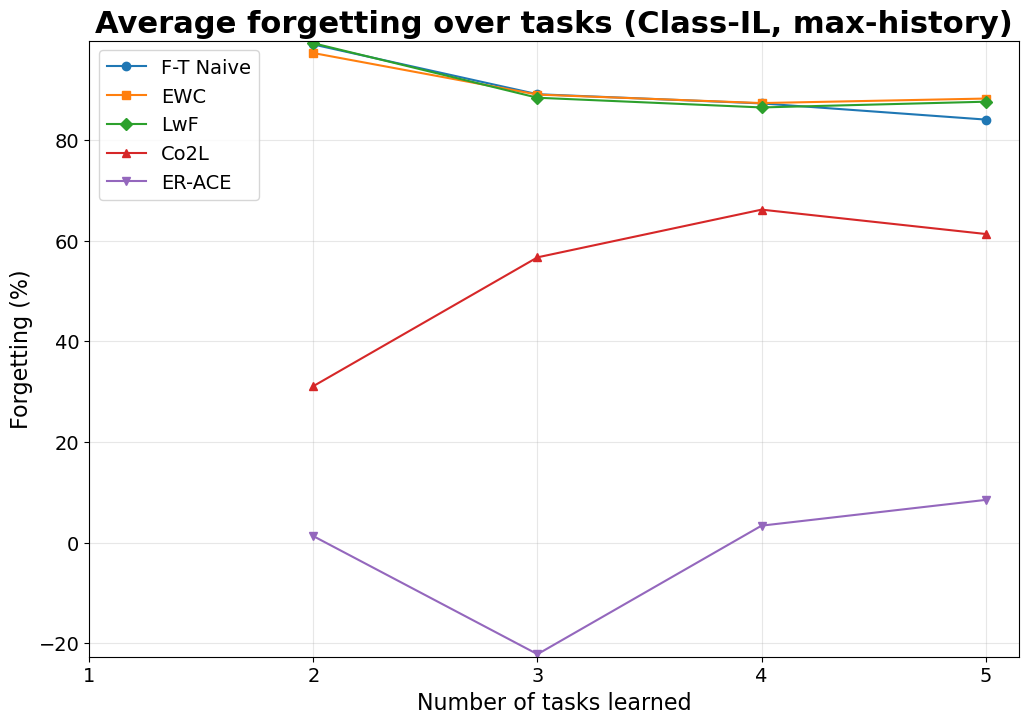

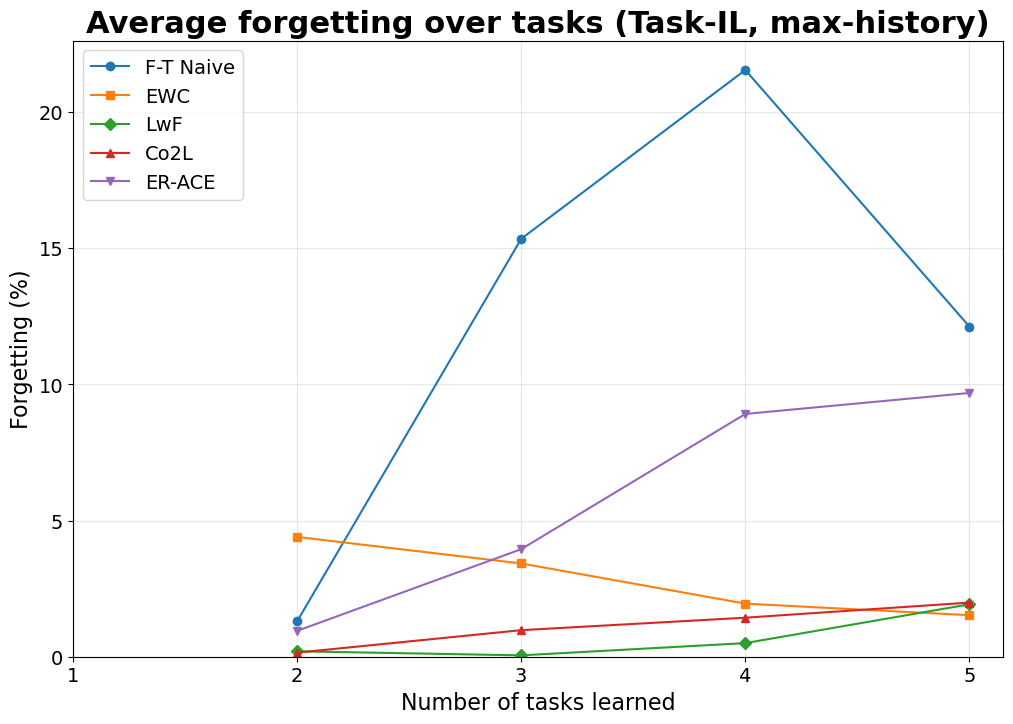

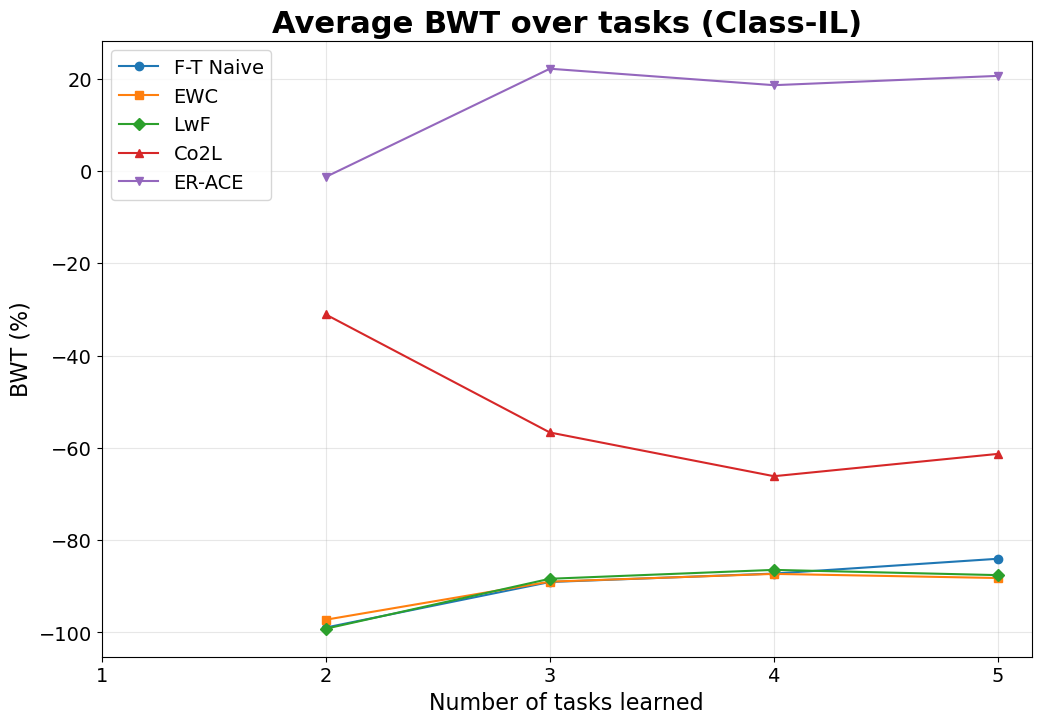

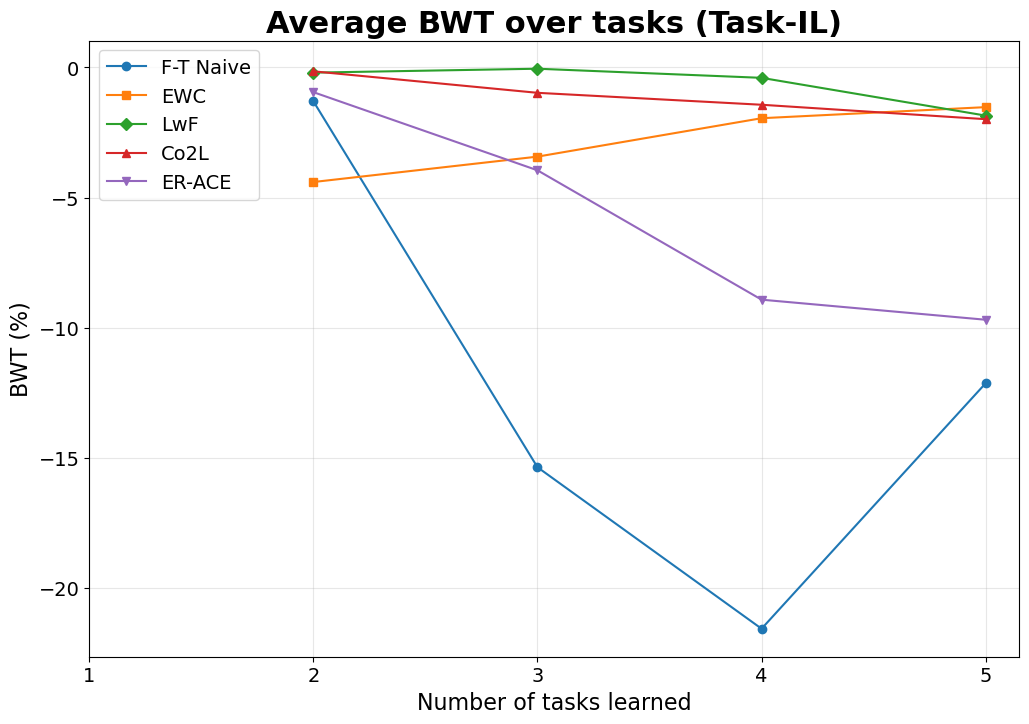

In [27]:
import pandas as pd
from IPython.display import display
from torch.utils.data import DataLoader

imgs_dir = Path("outputs/imgs")
imgs_dir.mkdir(parents=True, exist_ok=True)

methods_info = {
    "F-T Naive": ("naive_history", "naive_model"),
    "EWC": ("ewc_history", "ewc_model"),
    "LwF": ("lwf_history", "lwf_model"),
    "Co2L": ("co2l_history", "co2l_model"),
    "ER-ACE": ("er_ace_history", "er_ace_model")
}

method_histories = {}
method_models = {}

for name, (h_var, m_var) in methods_info.items():
    if h_var in globals():
        method_histories[name] = globals()[h_var]
    if m_var in globals():
        method_models[name] = globals()[m_var]

if not method_histories:
    print("No se encontraron historiales para comparar. Ejecuta las celdas de entrenamiento primero.")
else:
    print(f"Generando comparativa completa para: {', '.join(method_histories.keys())}")
    
    summary_data = []
    for name, hist in method_histories.items():
        res = {
            "Método": name,
            "Final Class-IL (%)": hist["class_il"][-1],
            "Final Task-IL (%)": hist["task_il"][-1],
        }
        
        # Métricas de transferencia para Class-IL
        if "taskwise_class_il_matrix" in hist:
            m_class = compute_final_transfer_metrics(hist["taskwise_class_il_matrix"])
            res["Forgetting (Class)"] = m_class["avg_forgetting_final"]
            res["BWT (Class)"] = m_class["avg_bwt_per_step"][-1]
            
        # Métricas de transferencia para Task-IL
        if "taskwise_task_il_matrix" in hist:
            m_task = compute_final_transfer_metrics(hist["taskwise_task_il_matrix"])
            res["Forgetting (Task)"] = m_task["avg_forgetting_final"]
            res["BWT (Task)"] = m_task["avg_bwt_per_step"][-1]
        
        summary_data.append(res)
    
    df_summary = pd.DataFrame(summary_data).set_index("Método")
    
    print("\n--- Resumen de Métricas Finales ---")
    display(df_summary)


    # Visualizaciones de Evolución (Comparativas)
    print("\nGenerando gráficos de evolución...")
    
    # Accuracy
    plot_methods_comparison_class_il(method_histories, save_path=imgs_dir / "comp_accuracy_class_il.png")
    plot_methods_comparison_task_il(method_histories, save_path=imgs_dir / "comp_accuracy_task_il.png")
    
    # Forgetting
    plot_forgetting_curves(method_histories, metric="class_il", save_path=imgs_dir / "comp_forgetting_class_il.png")
    plot_forgetting_curves(method_histories, metric="task_il", save_path=imgs_dir / "comp_forgetting_task_il.png")
    
    # BWT
    plot_bwt_curves(method_histories, metric="class_il", save_path=imgs_dir / "comp_bwt_class_il.png")
    plot_bwt_curves(method_histories, metric="task_il", save_path=imgs_dir / "comp_bwt_task_il.png")
    

## **Metricas adicionales**


Generando visualizaciones detalladas por método...


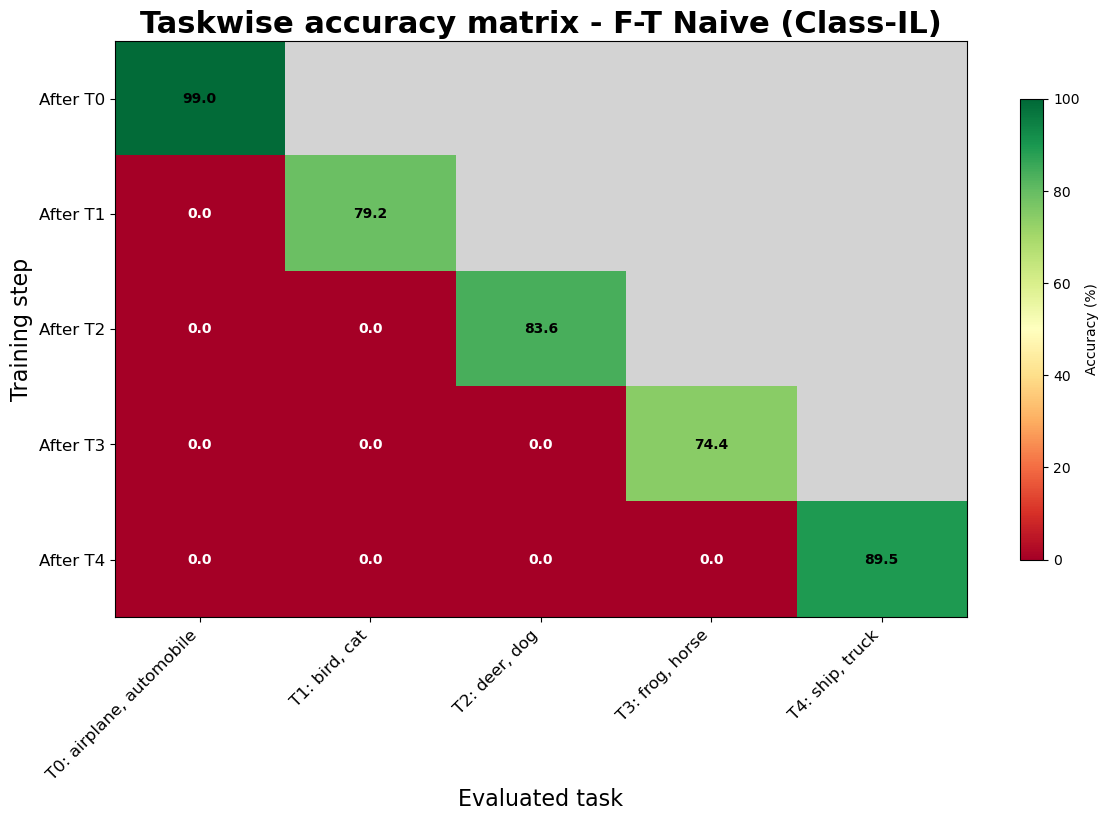

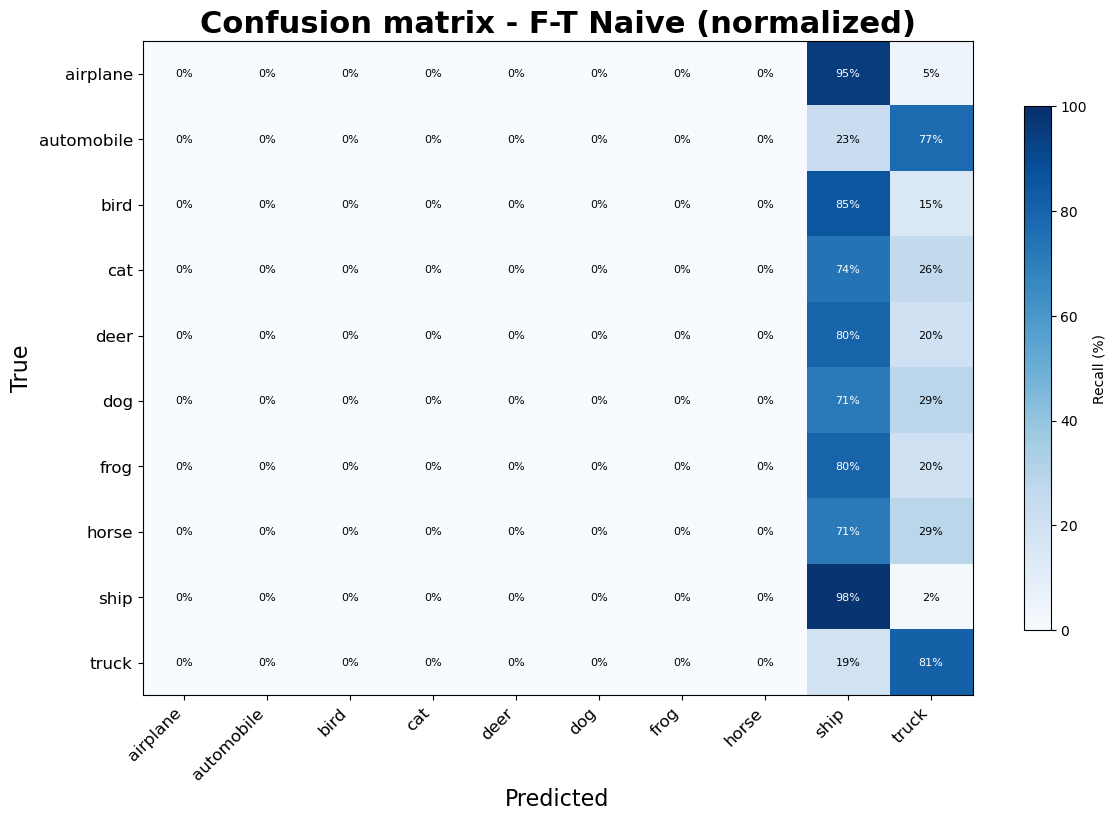

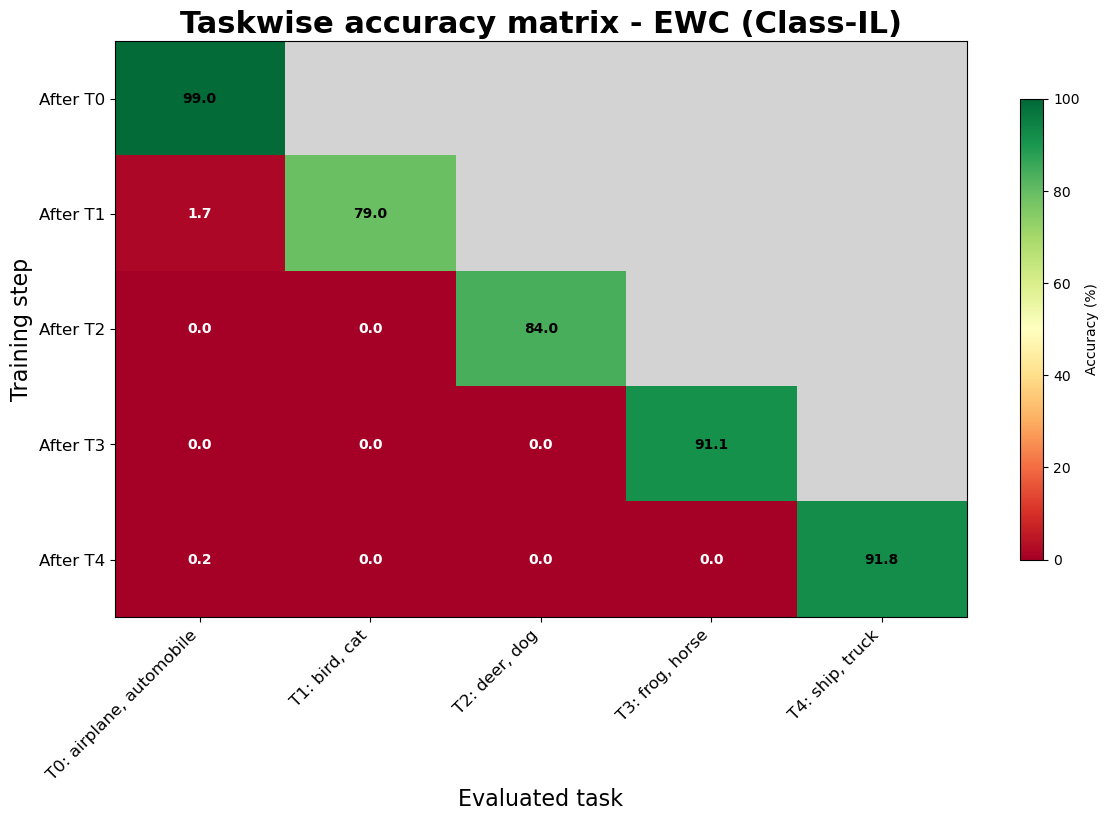

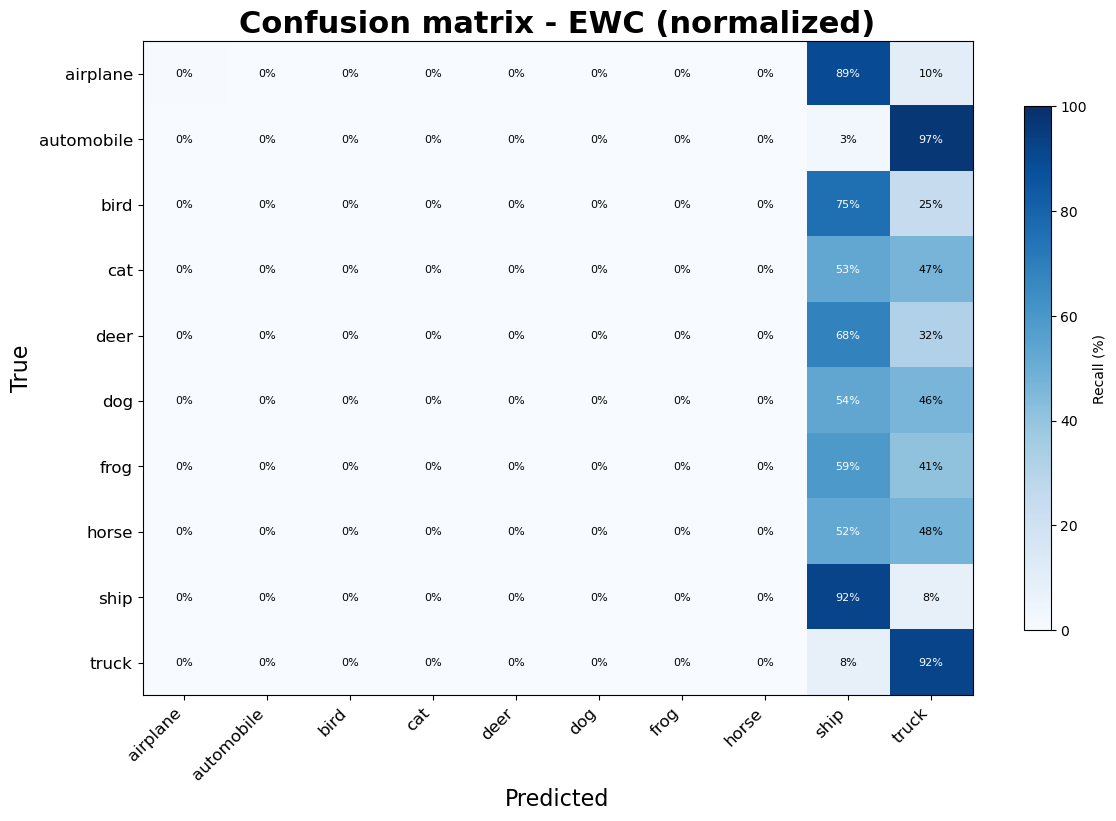

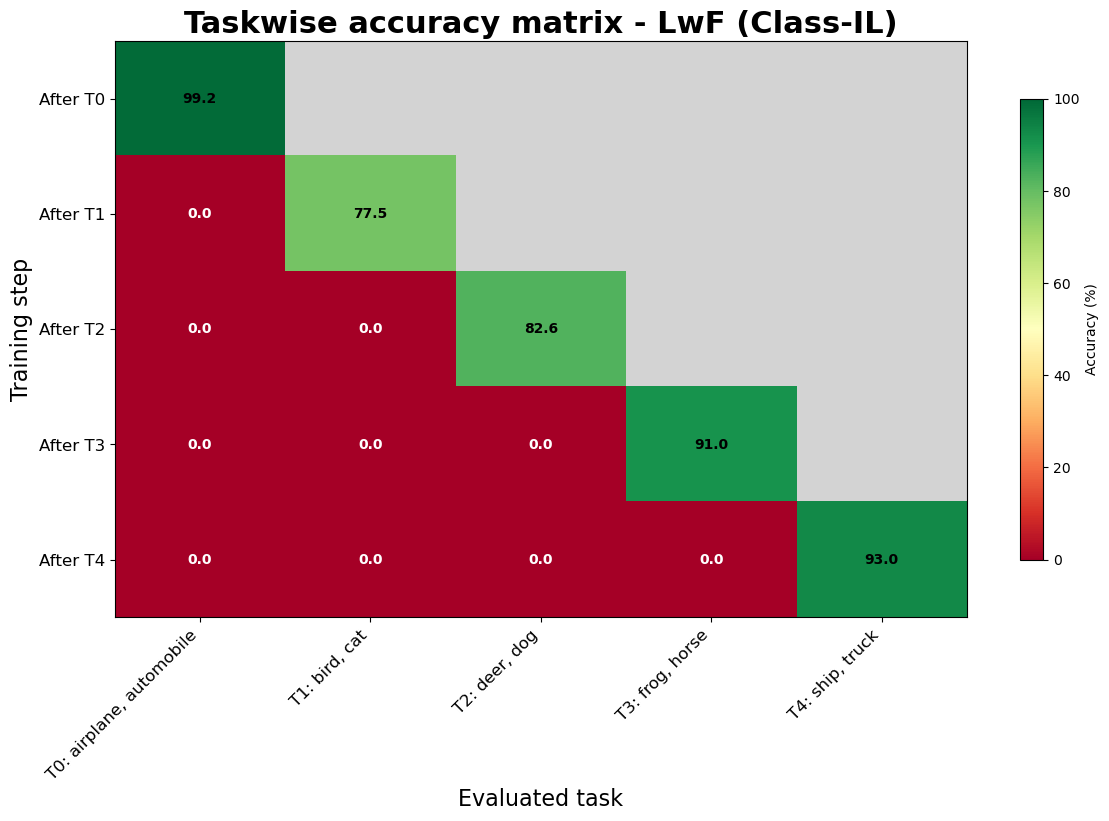

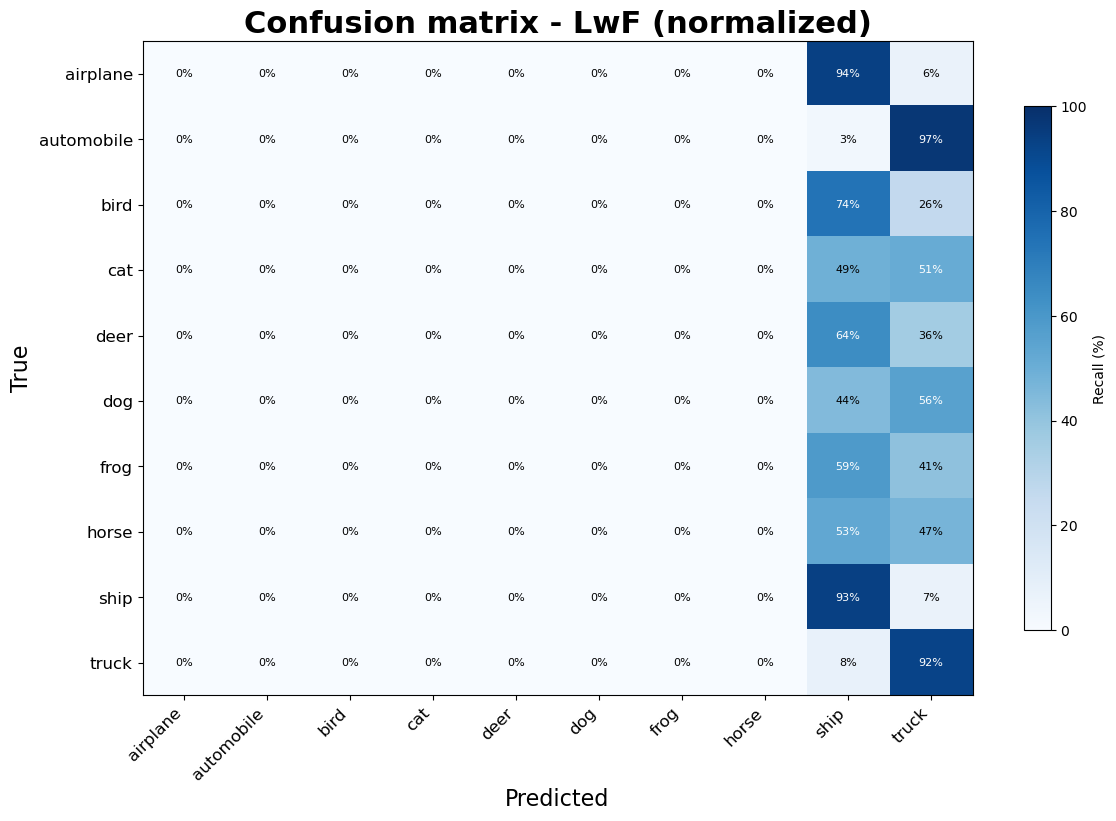

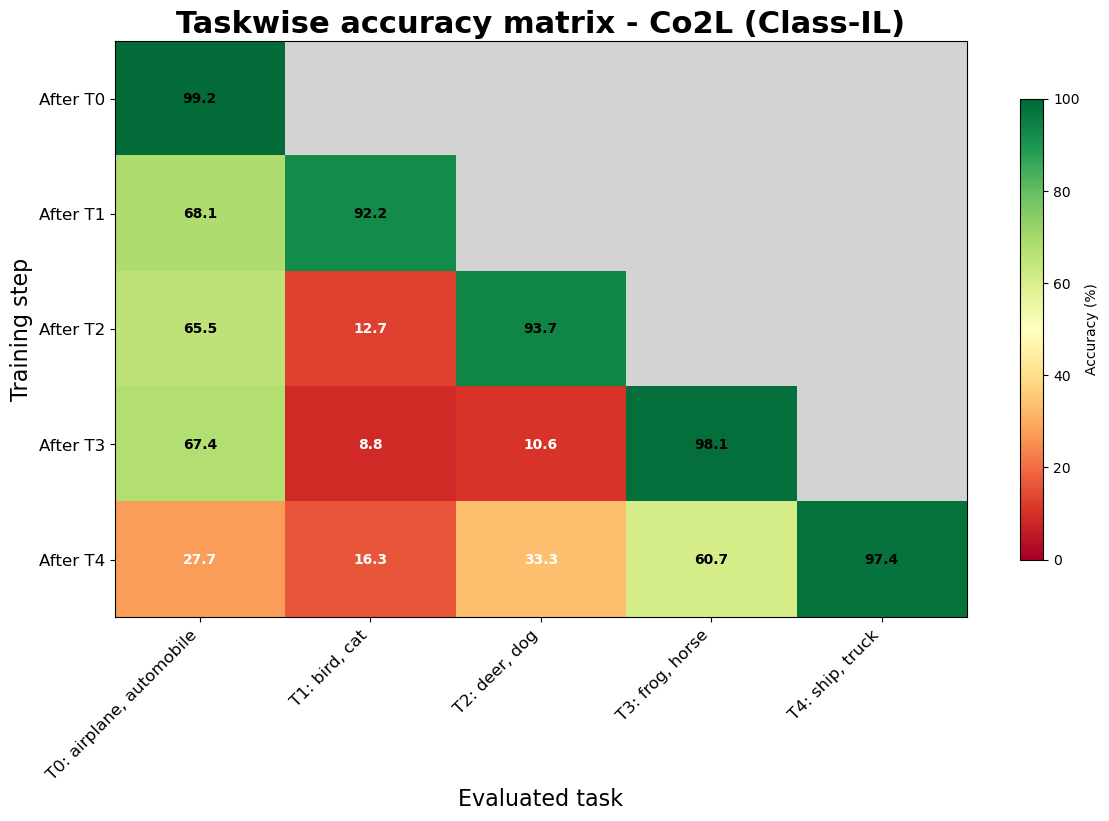

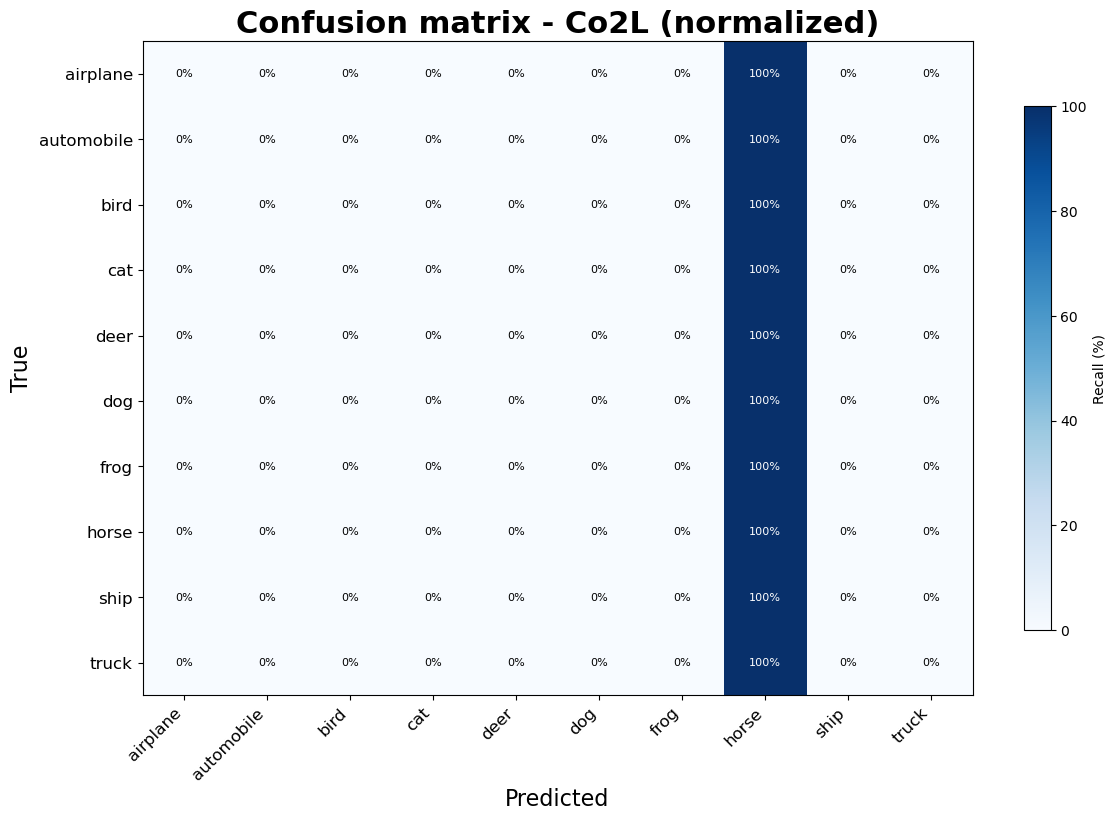

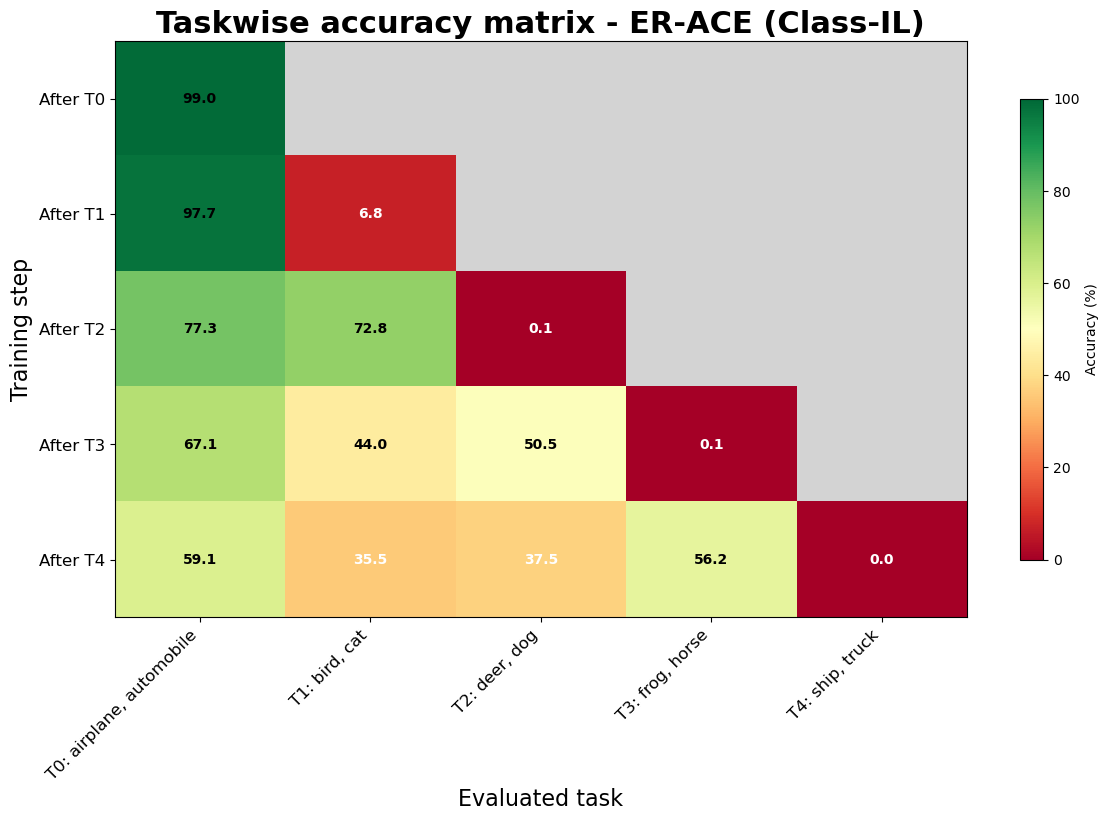

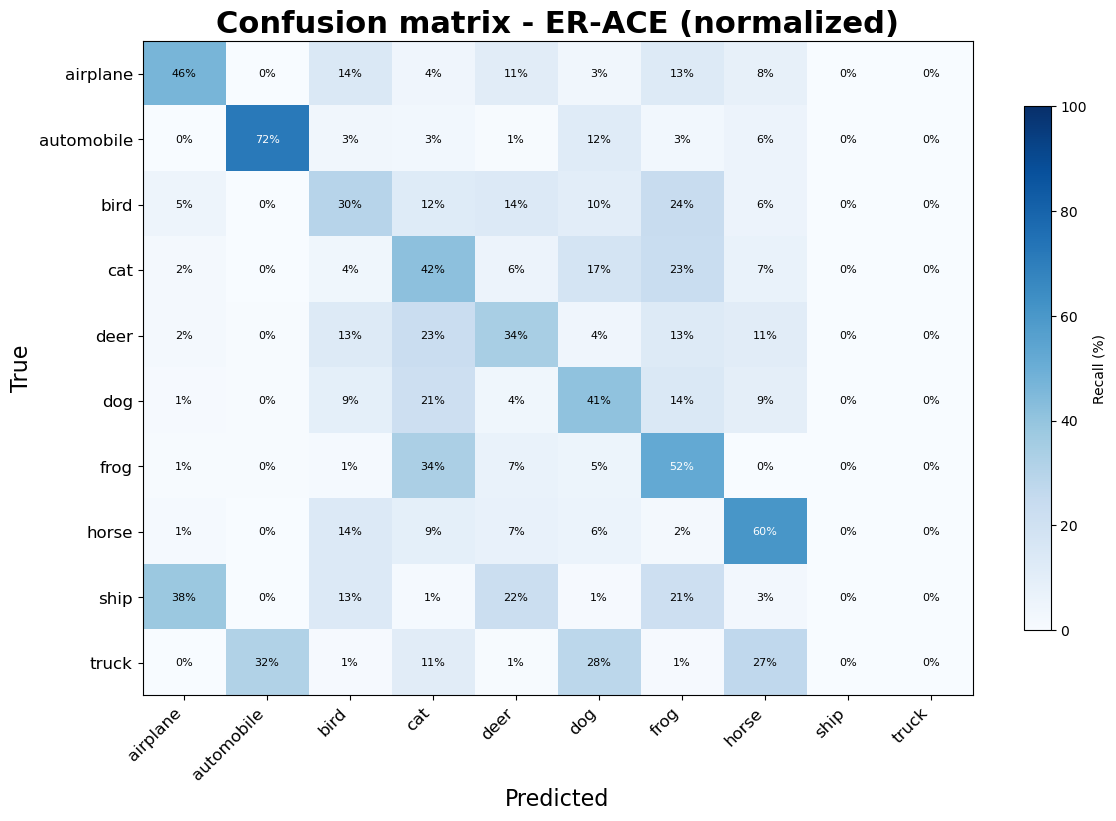

/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


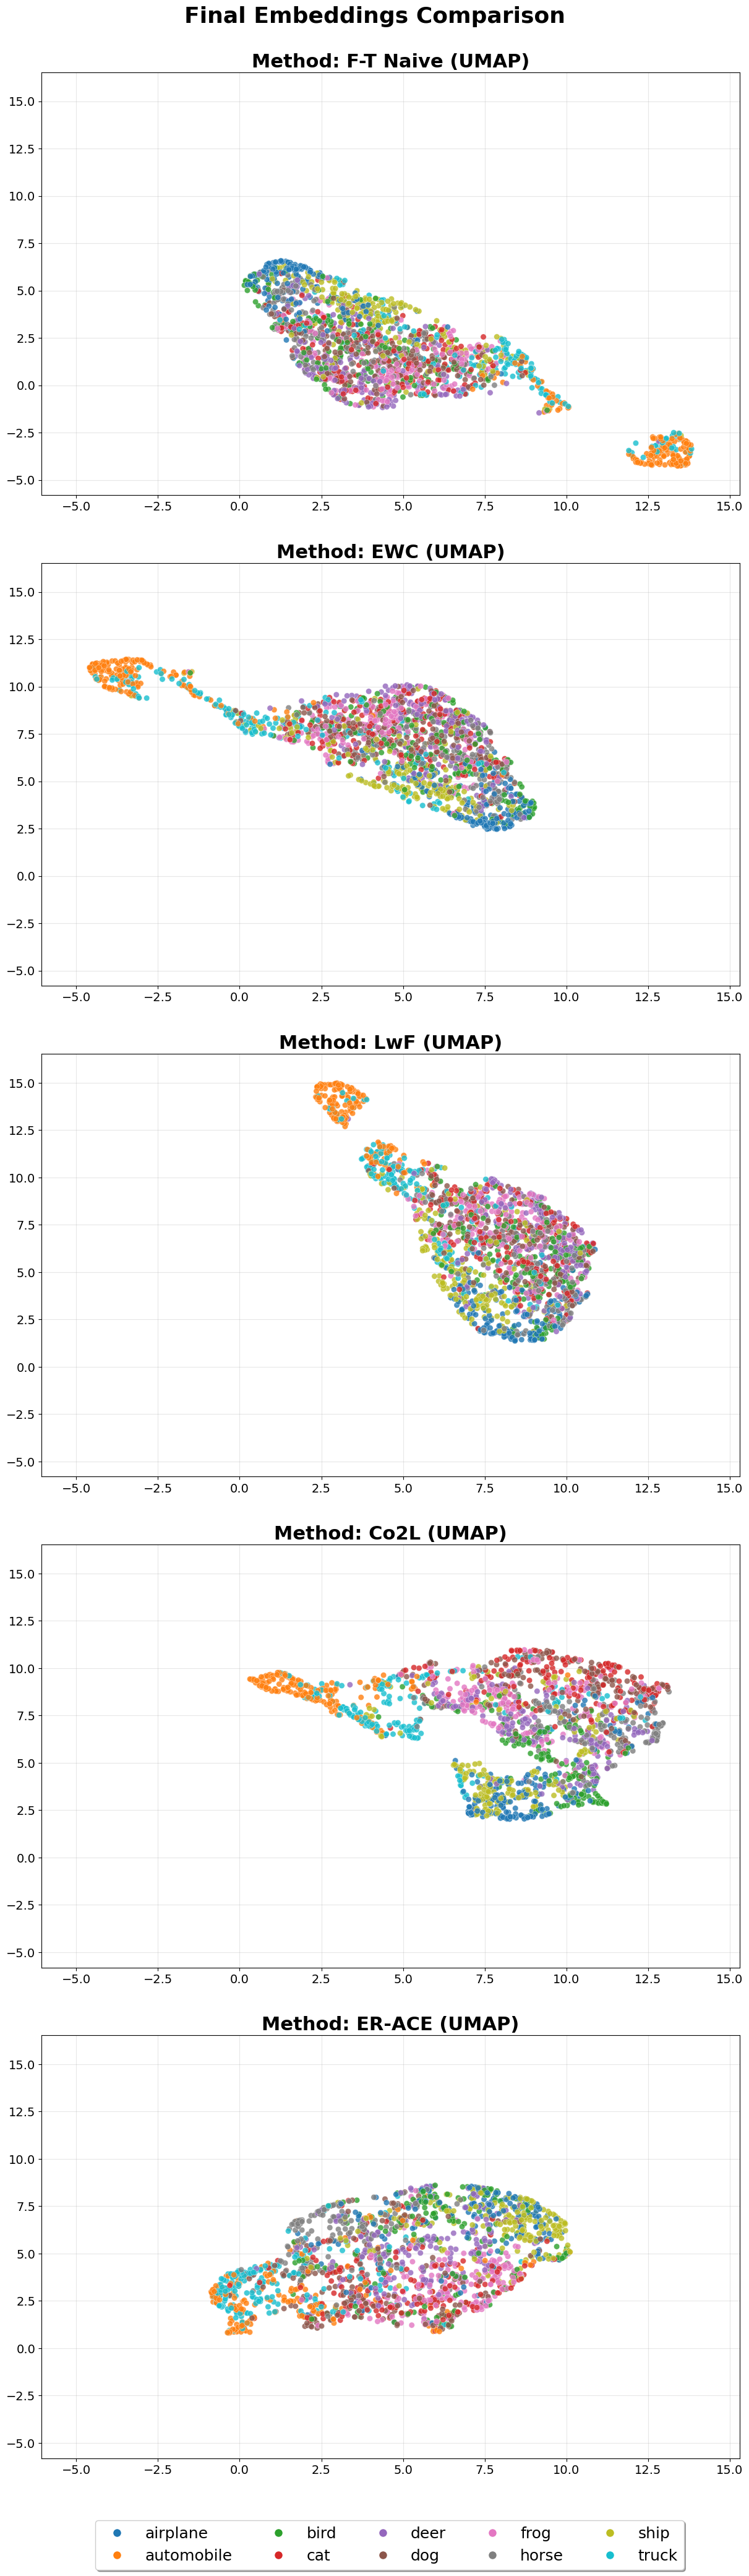

In [28]:
print("\nGenerando visualizaciones detalladas por método...")
test_ds_full = CIFAR10TaskDataset(seq_builder.test_base, indices=list(range(len(seq_builder.test_base))), transform=eval_transform)
test_loader_full = DataLoader(test_ds_full, batch_size=256, shuffle=False, **dataloader_kwargs)

embeddings_map = {}

for name in method_histories:
    hist = method_histories[name]
    safe_name = name.lower().replace("-", "_")
    
    # Heatmap
    if "taskwise_class_il_matrix" in hist:
        plot_taskwise_heatmap(hist["taskwise_class_il_matrix"], name, 
                                task_classes=seq_builder.task_classes, class_names=CIFAR10_CLASSES,
                                save_path=imgs_dir / f"heatmap_{safe_name}.png")
    
    # Matriz de Confusión 
    if name in method_models:
        model = method_models[name]
        model.eval()
        cm = get_confusion_matrix(model, test_loader_full, device=device)
        plot_confusion_matrix(cm, name, class_names=CIFAR10_CLASSES, 
                                save_path=imgs_dir / f"cm_{safe_name}.png")
        
        # Preparar embeddings para t-SNE
        backbone = model.backbone if hasattr(model, 'backbone') else model
        feats, labs = extract_features(backbone, test_loader_full, device=device)
        if isinstance(feats, (list, tuple)): feats = feats[0]
        embeddings_map[name] = (feats.cpu(), labs.cpu())


if embeddings_map:
    plot_final_embeddings_comparison(embeddings_map, class_names=CIFAR10_CLASSES, save_path=imgs_dir / "comp_embeddings.png")